Platform Expansion and Labour-Market Vulnerability in India: Evidence from the COVID-19 Shock and Employment Protection Gaps

#1. Project One

##1.1 Introduction

Over the past decade, India has experienced rapid growth in platform-mediated work driven by digitalization. Platform work refers to task-based labour coordinated through digital platforms where workers perform short-term services and classify as independent contractors (Wood et al., 2019). Such arrangements blur the boundary between self-employment and wage work, shifting economic risk toward workers while weakening employer liability. Estimates suggest India’s gig workforce could exceed 23 million by 2029–30, highlighting the relevance of platform-mediated labour (NITI Aayog, 2022).

A growing literature examines how this expansion affects job quality and labour-market security. Studies emphasize that platform work often operates under contractual ambiguity, algorithmic management, and piece-rate compensation structures that transfer employment risk onto workers (Wood et al., 2019; Parwez, 2022). Evidence documents limited written contracts and social security coverage among gig workers (Aggarwal, 2023; Koley, 2025; Bhattarai, 2025). Across perspectives, protection gaps emerge as the mechanism linking gig work to labour-market vulnerability (Pankaj & Jha, 2024; Sharma & Sharma, 2025).

The pandemic provides a natural test of this mechanism. Informal workers experienced disproportionate employment and income losses during COVID due to limited protection against labour-market shocks (Bussolo et al., 2021), while platform sectors faced earnings volatility despite operating in essential services (Rani & Dhir, 2020). However, limited evidence exists on how gig exposure and protection gaps vary across labour markets within India, as most studies focus on worker experiences or national trends.
This study addresses that gap by combining PLFS microdata with the CMIE Unemployment dataset to construct state-level labour-market indicators. The study asks: Did the COVID-19 shock increase states’ exposure to platform-adjacent employment in India (X), raising labour-market vulnerability (Y) through weaker employment protection (Z), proxied by the absence of written contracts and social security coverage? Descriptive evidence suggests a post-COVID rise in gig exposure with high vulnerable employment. State-level patterns indicate a positive association between X and Y, alongside heterogeneity in Z, motivating analysis of how gig expansion shapes labour-market outcomes.

##1.2 Data Cleaning / Loading

The assigned CMIE Unemployment dataset (2019–2020) reports monthly unemployment rates and labour force participation rates at the state × rural/urban level. While it captures high-frequency labour-market conditions, it lacks worker-level characteristics, employment protection measures and has limited temporal coverage.

1.2.1 Other Datasets

To measure the mechanism and extend coverage, CMIE data are merged with Periodic Labour Force Survey (PLFS) microdata (2018–2024) from the Government of India. PLFS provides nationally representative information on employment status, occupation, enterprise type, workplace attachment, contract status, social security coverage, and worker demographics. PLFS observations are aggregated using survey weights to the state × year × quarter × rural/urban level, while CMIE indicators are averaged to quarterly frequency. The merged dataset forms a state-level quarterly panel, enabling pre- and post-COVID comparisons and incorporating gig-specific variables unavailable in CMIE.

1.2.2 Key Variables

The outcome variable (Y) is vulnerable employment share, defined by the ILO as the proportion of employed workers who are own-account workers or unpaid family workers, capturing weak job security and limited institutional protection.

The mechanism variable (Z) is a Gig Precarity Index, constructed as the arithmetic mean of three protection-deficit indicators: absence of a written contract, lack of paid leave or employment benefits, and absence of social security coverage.

The main explanatory variable (X) is gig employment share, measured as the proportion of workers whose principal activity is classified as platform-adjacent work. This variable captures labour-market exposure to platform-mediated employment.

Additional variables include Gig volatility wedge, constructed as the absolute difference between gig employment measured under principal status (main occupation over the year) and current weekly status (employment during the reference week), proxies short-term employment instability. Structural controls further include the share of gig workers in small or informal enterprises and the share without a fixed workplace, reflecting weak firm attachment and limited regulatory oversight.

Demographic composition variables capture worker sorting into gig employment. These include the share of gig workers aged 15–34, the share with secondary or tertiary education, and the male-to-female ratio within gig employment. Younger workers often enter gig work due to limited access to stable jobs, educational composition reflects heterogeneity in skill levels across platform occupations, and the gender ratio captures labour-market segmentation, particularly male concentration in certain gig-sectors. These variables capture worker characteristics that may influence vulnerability across gig exposure levels.

Industrial composition controls account for sectoral differences in gig expansion, including the shares of gig workers in transport, food and delivery, and personal services. These sectors differ in earnings stability and regulation; controlling for it isolates whether gig exposure affects labour-market vulnerability through the mechanism.

In [8]:
# ======================
# Load datasets
# ======================
import pandas as pd
import numpy as np

plfs = pd.read_csv("plfs_2018_2024.csv")
unemp = pd.read_csv("unemp_quarterly_agg.csv")

# ======================
# 1) Standardize PLFS keys
# ======================
for c in ["year_label", "quarter", "state"]:
    plfs[c] = plfs[c].astype(str).str.strip()

# Ensure PLFS has a "region" column (Rural/Urban)
if "region" not in plfs.columns:
    if "sector_ru" in plfs.columns:
        plfs["region"] = plfs["sector_ru"]
    elif "sector" in plfs.columns:
        plfs["region"] = plfs["sector"].map({1: "Rural", 2: "Urban", "1": "Rural", "2": "Urban"})
    else:
        raise KeyError("PLFS must have either 'region', 'sector_ru', or 'sector'.")

plfs["region"] = plfs["region"].astype(str).str.strip().str.title()

# Standardize quarter format
plfs["quarter"] = (
    plfs["quarter"].astype(str).str.strip().str.upper()
        .replace({"1": "Q1", "2": "Q2", "3": "Q3", "4": "Q4"})
)

# ======================
# 2) Standardize UNEMPLOYMENT keys
# ======================
for c in ["year_label", "quarter", "state", "sector_ru"]:
    if c not in unemp.columns:
        raise KeyError(f"Unemp is missing '{c}'. Found: {list(unemp.columns)}")
    unemp[c] = unemp[c].astype(str).str.strip()

unemp["region"] = unemp["sector_ru"].astype(str).str.strip().str.title()
unemp["quarter"] = (
    unemp["quarter"].astype(str).str.strip().str.upper()
        .replace({"1": "Q1", "2": "Q2", "3": "Q3", "4": "Q4"})
)

# (Optional) drop sector_ru now that region exists
unemp = unemp.drop(columns=["sector_ru"], errors="ignore")

# ======================
# 3) Merge: KEEP ALL PLFS OBS (LEFT JOIN)
# ======================
keys = ["year_label", "quarter", "state", "region"]

plfs["_in_plfs"] = 1
unemp["_in_unemp"] = 1

merged = plfs.merge(unemp, on=keys, how="left")

merged["_in_plfs"] = merged["_in_plfs"].fillna(0).astype(int)
merged["_in_unemp"] = merged["_in_unemp"].fillna(0).astype(int)

# ======================
# 4) Sort earliest -> latest (fiscal-year start)
# ======================
merged["fy_start"] = pd.to_numeric(merged["year_label"].str[:4], errors="coerce")
qmap = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
merged["q_num"] = merged["quarter"].map(qmap)

region_order = {"Rural": 0, "Urban": 1}
merged["region_order"] = merged["region"].map(region_order).fillna(2)

merged = (
    merged.sort_values(["fy_start", "q_num", "state", "region_order"])
          .drop(columns=["fy_start", "q_num", "region_order", "_in_plfs", "unemployment_rate_pct", "lfpr_pct", "_in_unemp"])
          .reset_index(drop=True)
)

# ======================
# 5) Save
# ======================
out_path = "final_dataset.csv"
merged.to_csv(out_path, index=False)
print("Saved:", out_path)
print("PLFS rows:", len(plfs), "| Merged rows (should match PLFS):", len(merged))


Saved: final_dataset.csv
PLFS rows: 1691 | Merged rows (should match PLFS): 1691


##1.3 Summary Statistics Tables

In [25]:
# Summary Tables
import numpy as np
from IPython.display import HTML, display

# ======================
# 1. Load and Process Data 
# ======================
df = pd.read_csv("final_dataset.csv") 

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Define Variables
Y = "vulnerable_employment_share"
Z = "gig_precarity_index"
X_gig_share = "gig_employment_share_principal"
X_wedge = "gig_volatility_wedge_occ"
X_informal_enterprise = "gig_num_workers_enterprise_share"
X_no_fixed_workplace = "gig_workplace_location_code_share"

# Create new X variables
df["X_gig_age_15_34_share_within_gig"] = to_num(df["gig_age_15_24_share_within_gig"]) + to_num(df["gig_age_25_34_share_within_gig"])
df["X_gig_edu_secondary_tertiary_share_within_gig"] = to_num(df["gig_edu_secondary_share_within_gig"]) + to_num(df["gig_edu_tertiary_share_within_gig"])
df["X_gig_male_female_ratio"] = to_num(df["gig_male_share_within_gig"]) / to_num(df["gig_female_share_within_gig"]).replace(0, np.nan)

X_transport = "gig_transport_share_within_gig"
X_food = "gig_delivery_food_share_within_gig"
X_personal = "gig_personal_other_share_within_gig"

vars_main = [Y, Z, X_gig_share, X_wedge, X_informal_enterprise, X_no_fixed_workplace, 
             "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", "X_gig_male_female_ratio", X_transport, X_food, X_personal]

clean_labels = {
    Y: "Vulnerable employment share (%): Y",
    Z: "Gig Precarity Index (0-1): Z",
    X_gig_share: "Gig exposure share (%)",
    X_wedge: "Gig volatility wedge (pp)",
    X_informal_enterprise: "Small/Informal enterprise share (%)",
    X_no_fixed_workplace: "No fixed workplace share (%)",
    "X_gig_age_15_34_share_within_gig": "Gig workers aged 15–34 (%)",
    "X_gig_edu_secondary_tertiary_share_within_gig": "Gig workers with secondary & tertiary education (%)",
    "X_gig_male_female_ratio": "Male-to-female ratio (within gig)",
    X_transport: "Transport service share (%)", 
    X_food : "Food & Delivery service share (%)", 
    X_personal : "Personal & Other service share (%)"
}

# Compute stats
df_summary = df[vars_main].apply(pd.to_numeric, errors='coerce').dropna(how='all')
share_cols = [Y, X_gig_share, X_informal_enterprise, X_no_fixed_workplace, 
              "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", X_wedge]
df_summary[share_cols] = df_summary[share_cols] * 100

stats = pd.DataFrame({
    "Mean": df_summary.mean(numeric_only=True),
    "St. Dev.": df_summary.std(numeric_only=True),
    "Min": df_summary.min(numeric_only=True),
    "Max": df_summary.max(numeric_only=True),
})

# ======================
# 2. Compact HTML Rendering
# ======================
# Reduced width to 65%, font-sizes lowered, and padding tightened
html_output = f"""
<div align="center" style="margin: 20px 0;">
    <table border="1" style="border-collapse: collapse; font-family: 'Times New Roman', Times, serif; font-size: 13px; border: 2px solid black; width: 85%;">
        <caption style="font-size: 16px; margin-bottom: 10px; font-weight: bold; color: black; text-align: center;">
            Table 1.3.1: Summary Statistics (Key Variables)
        </caption>
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 8px; text-align: left; border: 1px solid black; font-size: 13px; width: 40%;">Variable</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px; width: 15%;">Mean</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px; width: 15%;">St. Dev.</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px; width: 15%;">Min</th>
            <th style="padding: 6px; text-align: center; border: 1px solid black; font-size: 13px; width: 15%;">Max</th>
        </tr>
"""

for var in stats.index:
    label = clean_labels.get(var, var)
    html_output += f"""
        <tr>
            <td style="padding: 7px 10px; border: 1px solid black; text-align: left;">{label}</td>
            <td style="padding: 7px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'Mean']:.3f}</td>
            <td style="padding: 7px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'St. Dev.']:.3f}</td>
            <td style="padding: 7px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'Min']:.3f}</td>
            <td style="padding: 7px 10px; border: 1px solid black; text-align: center;">{stats.loc[var, 'Max']:.3f}</td>
        </tr>
    """


    
html_output += """
    </table>
</div>
"""

display(HTML(html_output)) 

Variable,Mean,St. Dev.,Min,Max
Vulnerable employment share (%): Y,43.463,17.483,0.000,85.098
Gig Precarity Index (0-1): Z,0.248,0.148,0.000,1.000
Gig exposure share (%),49.168,19.327,0.638,94.269
Gig volatility wedge (pp),0.648,1.241,0.000,19.336
Small/Informal enterprise share (%),55.430,18.976,0.000,99.335
No fixed workplace share (%),4.437,4.479,0.000,49.902
Gig workers aged 15–34 (%),33.018,11.703,0.000,100.000
Gig workers with secondary & tertiary education (%),62.942,15.320,0.000,100.000
Male-to-female ratio (within gig),10.156,140.971,0.180,5508.093
Transport service share (%),0.078,0.071,0.000,0.798


Table 1.3.1 shows that vulnerable employment is high on average (43.5%) and widely dispersed, indicating substantial heterogeneity in employment security. Gig exposure is sizable, with an average share of about 49% and large cross-market variation, suggesting that platform-mediated work is concentrated rather than uniformly distributed.

The structural variables align with the proposed mechanism. The gig volatility wedge has a low mean (0.65 pp) but a large maximum (19.3 pp), indicating that while gig work appears stable in many markets, some experience substantial short-horizon employment instability. Similarly, the share of gig workers in small or informal enterprises averages about 55% and varies widely, while the share without a fixed workplace is also highly dispersed. These patterns reflect heterogeneous employment arrangements where enforcement of contracts and social security protections is weaker.

Compositional and sectoral patterns further contextualize gig employment. Gig work is youth-skewed (33% workers aged 15–34) and moderately educated (63% with secondary or tertiary education), suggesting vulnerability reflects institutional features rather than skill deficits alone. The gender ratio varies widely, indicating segmentation. Sectorally, gig work is concentrated in food and delivery (23%) and transport (8%), with smaller shares in personal services (3%), consistent with platform expansion in task-based, app-mediated sectors. These patterns indicate a segmented labour market where gig exposure coexists with informality and employment instability, consistent with Z linking X to Y.

In [26]:
# Pre vs Post- COVID
from IPython.display import HTML, display

# =====================================================
# 1. Load Data and Re-calculate Needed Columns
# =====================================================
df = pd.read_csv("final_dataset.csv") 

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Define Variables and Unit Logic
Y = "vulnerable_employment_share"
Z = "gig_precarity_index"
X_gig_share = "gig_employment_share_principal"
X_wedge = "gig_volatility_wedge_occ"
X_informal_enterprise = "gig_num_workers_enterprise_share"
X_no_fixed_workplace = "gig_workplace_location_code_share"

# RE-CALCULATE COLUMNS 
df["X_gig_age_15_34_share_within_gig"] = to_num(df["gig_age_15_24_share_within_gig"]) + to_num(df["gig_age_25_34_share_within_gig"])
df["X_gig_edu_secondary_tertiary_share_within_gig"] = to_num(df["gig_edu_secondary_share_within_gig"]) + to_num(df["gig_edu_tertiary_share_within_gig"])
df["X_gig_male_female_ratio"] = to_num(df["gig_male_share_within_gig"]) / to_num(df["gig_female_share_within_gig"]).replace(0, np.nan)

X_transport = "gig_transport_share_within_gig"
X_food = "gig_delivery_food_share_within_gig"
X_personal = "gig_personal_other_share_within_gig"

vars_main = [Y, Z, X_gig_share, X_wedge, X_informal_enterprise, X_no_fixed_workplace, 
             "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", "X_gig_male_female_ratio", X_transport, X_food, X_personal]

clean_labels = {
    Y: "Vulnerable employment share (%): Y",
    Z: "Gig Precarity Index (0-1): Z",
    X_gig_share: "Gig exposure share (%)",
    X_wedge: "Gig volatility wedge (pp)",
    X_informal_enterprise: "Small/Informal enterprise share (%)",
    X_no_fixed_workplace: "No fixed workplace share (%)",
    "X_gig_age_15_34_share_within_gig": "Gig workers aged 15–34 (%)",
    "X_gig_edu_secondary_tertiary_share_within_gig": "Gig workers with secondary & tertiary education (%)",
    "X_gig_male_female_ratio": "Male-to-female ratio (within gig)",
    X_transport: "Transport service share (%)", 
    X_food : "Food & Delivery service share (%)", 
    X_personal : "Personal & Other service share (%)"
}

# =====================================================
# 2. Build COVID Subgroups
# =====================================================
df["year_num"] = pd.to_numeric(df["year_label"].astype(str).str[:4], errors="coerce")
df["covid_period"] = pd.Series(pd.NA, index=df.index, dtype="object")
df.loc[df["year_num"].between(2018, 2020), "covid_period"] = "Pre-COVID (2018–2020)"
df.loc[df["year_num"].between(2022, 2024), "covid_period"] = "Post-COVID (2022–2024)"

df_sub = df[df["covid_period"].notna()].copy()
df_sub_summary = df_sub[["covid_period"] + vars_main].copy()

# Unit Conversions
share_cols = [Y, X_gig_share, X_informal_enterprise, X_no_fixed_workplace, 
              "X_gig_age_15_34_share_within_gig", "X_gig_edu_secondary_tertiary_share_within_gig", X_wedge]
df_sub_summary[share_cols] = df_sub_summary[share_cols] * 100

def summary_stats(gdf):
    return pd.DataFrame({
        "Mean": gdf.mean(numeric_only=True),
        "St. Dev.": gdf.std(numeric_only=True),
        "Min": gdf.min(numeric_only=True),
        "Max": gdf.max(numeric_only=True),
    }).loc[vars_main]

stats_pre  = summary_stats(df_sub_summary[df_sub_summary["covid_period"] == "Pre-COVID (2018–2020)"])
stats_post = summary_stats(df_sub_summary[df_sub_summary["covid_period"] == "Post-COVID (2022–2024)"])

# =====================================================
# 3. Side-by-Side Rendering with 4-Sided Borders
# =====================================================

def get_table_html(stats_df, title):
    tbl_html = f"""
    <div style="flex:1;">
        <table border="1" style="border-collapse: collapse; font-family: 'Times New Roman', Times, serif; font-size: 13px; border: 2px solid black; width: 100%; table-layout: fixed;">
            <caption style="font-size: 18px; margin-bottom: 10px; font-weight: bold; text-align: center; color: black;">
                {title}
            </caption>
            <tr style="background-color: #f2f2f2;">
                <th style="padding: 10px 5px; text-align: left; border: 1px solid black; font-size: 14px; width: 40%;">Variable</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">Mean</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">St. Dev.</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">Min</th>
                <th style="padding: 10px 2px; text-align: center; border: 1px solid black; font-size: 14px; width: 15%;">Max</th>
            </tr>
    """
    for var in stats_df.index:
        label = clean_labels.get(var, var)
        tbl_html += f"""
            <tr>
                <td style="padding: 6px 8px; border: 1px solid black; text-align: left; overflow: hidden; word-wrap: break-word;">{label}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'Mean']:.3f}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'St. Dev.']:.3f}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'Min']:.3f}</td>
                <td style="padding: 6px 2px; border: 1px solid black; text-align: center;">{stats_df.loc[var, 'Max']:.3f}</td>
            </tr>
        """
    tbl_html += "</table></div>"
    return tbl_html

final_html = f"""
<div style="display:flex; gap:15px; align-items:flex-start; margin: 30px 0; width: 100%; max-width: 100%;">
    {get_table_html(stats_pre, "Table 1.3.2A: Pre-COVID (2018-2020)")}
    {get_table_html(stats_post, "Table 1.3.2B: Post-COVID (2022-2024)")}
</div>
"""

display(HTML(final_html))


Variable,Mean,St. Dev.,Min,Max
Vulnerable employment share (%): Y,43.509,17.236,0.000,85.098
Gig Precarity Index (0-1): Z,0.266,0.164,0.000,1.000
Gig exposure share (%),37.759,12.644,0.638,85.196
Gig volatility wedge (pp),0.821,1.524,0.000,19.336
Small/Informal enterprise share (%),44.793,15.402,0.000,99.335
No fixed workplace share (%),5.192,4.896,0.000,49.902
Gig workers aged 15–34 (%),35.248,12.993,0.000,100.000
Gig workers with secondary & tertiary education (%),64.010,15.045,0.000,100.000
Male-to-female ratio (within gig),15.517,201.854,0.180,5508.093
Transport service share (%),0.087,0.076,0.000,0.798


Subgroup Analysis

Table 1.3.2 compares labour-market conditions before and after COVID-19. Gig exposure rises sharply from 37.8% to 60.6%, indicating substantial expansion of platform-mediated work. However, vulnerable employment remains persistently high, suggesting that increased gig participation did not improve employment security.

Structural indicators support the proposed mechanism as gig volatility wedge declines (082 to 0.47 pp), indicating greater stability in gig participation, although dispersion persists. Simultaneously, the share of gig workers in small or informal enterprises increases markedly from 44.8% to 66.6%, implying that much of the expansion occurred within structures with weaker labour protections.

Compositional changes are modest: the youth share declines slightly and the education profile remains broadly stable, suggesting gig growth was not driven by shifts in worker skill composition. Gender segmentation narrows but remains pronounced. Sectorally, gig activity remains concentrated in food and delivery services and transport, with only modest post-COVID diversification. Overall, the rise in gig exposure coincides with persistent vulnerability and increased informality.

##1.4 Plots, Histograms, Figures

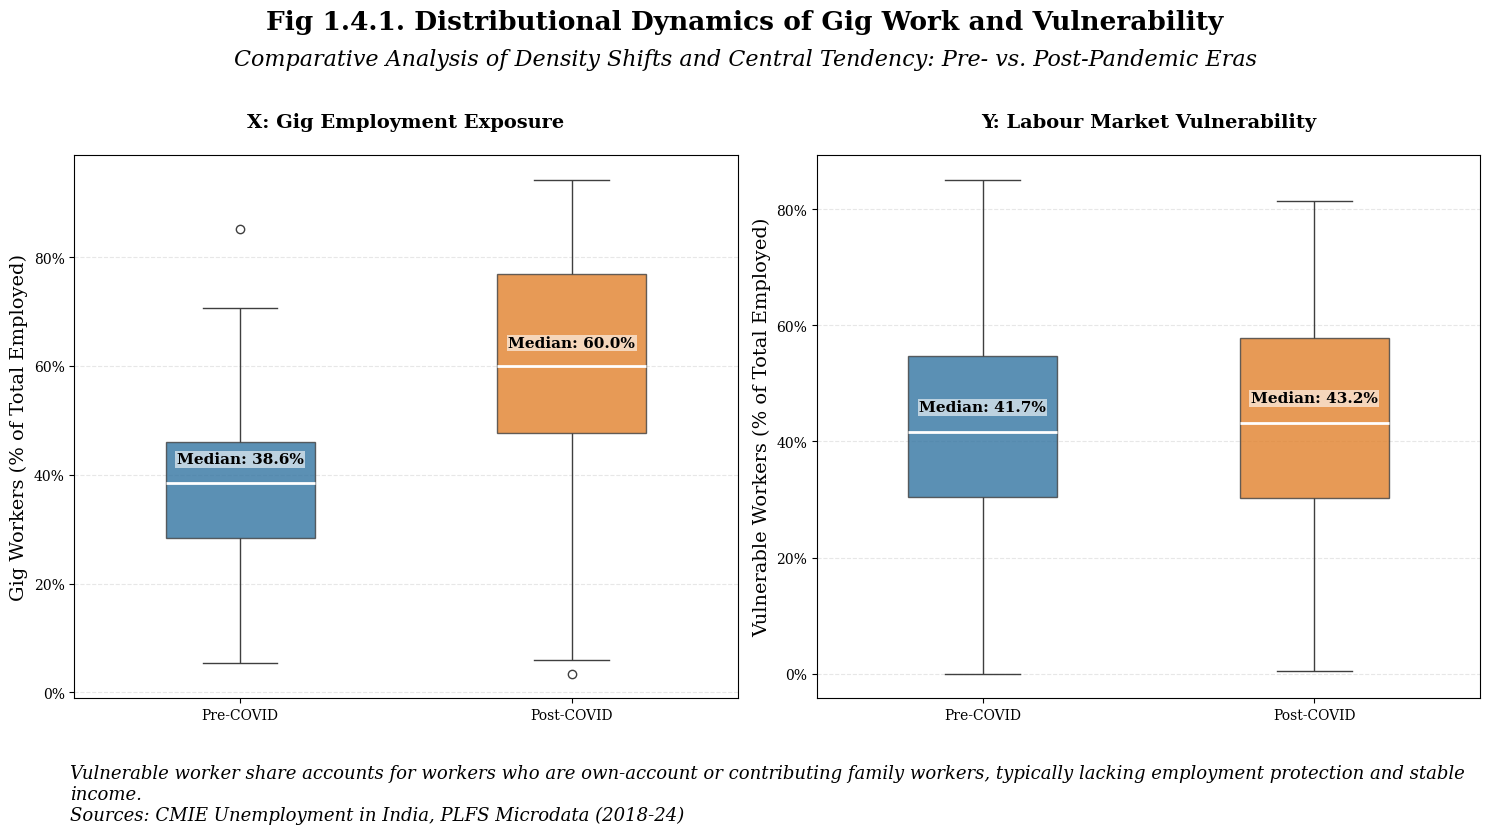

In [11]:
# Visualization 1 - Distributions of X and Y
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import pandas as pd # Ensure pandas is available
warnings.filterwarnings('ignore', category=FutureWarning)

# --- 1. Data Preparation (Fixes the KeyError) ---
def get_period(label):
    if label in ["2018_19", "2019_20"]: return "Pre-COVID"
    if label in ["2022_23", "2023_24"]: return "Post-COVID"
    return None

df['period'] = df['year_label'].apply(get_period)

# --- 2. Typography & Setup ---
plt.rcParams.update({"font.family": "serif"})
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
colors = {"Pre-COVID": "#1f77b4", "Post-COVID": "#ff7f0e"}

def plot_raincloud(ax, variable, title, ylabel):
    data = df[[variable, 'period']].dropna()

    # Boxplot only — rain and violin removed
    sns.boxplot(x="period", y=variable, hue="period", data=data, palette=colors,
                ax=ax, width=0.45, zorder=10, showcaps=True, legend=False,
                boxprops={'alpha': 0.8}, medianprops={'color': 'white', 'linewidth': 2})
    
    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Annotate medians
    for i, p in enumerate(["Pre-COVID", "Post-COVID"]):
        subset = data[data['period'] == p][variable]
        if not subset.empty:
            med = subset.median()
            ax.text(i, med + 0.03, f"Median: {med:.1%}", ha='center', va='bottom',
            color='black', fontsize=11, fontweight='bold', zorder=20,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# --- 3. Execute Plotting ---
X_exposure = "gig_employment_share_principal" 

plot_raincloud(axes[0], X_exposure, 
               "X: Gig Employment Exposure", "Gig Workers (% of Total Employed)")
plot_raincloud(axes[1], "vulnerable_employment_share", 
               "Y: Labour Market Vulnerability", "Vulnerable Workers (% of Total Employed)")

fig.suptitle("Fig 1.4.1. Distributional Dynamics of Gig Work and Vulnerability", 
             fontsize=19, fontweight='bold', y=0.96)

fig.text(0.5, 0.89, 
         "Comparative Analysis of Density Shifts and Central Tendency: Pre- vs. Post-Pandemic Eras", 
         ha="center", fontsize=16, style='italic')

footnote_text = ("Vulnerable worker share accounts for workers who are own-account or contributing family workers, typically lacking employment protection and stable income.\n"
"Sources: CMIE Unemployment in India, PLFS Microdata (2018-24)")
fig.text(0.05, -0.05, footnote_text, ha="left", fontsize=13, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

Motivation- To assess whether the COVID shock coincided with distributional shifts in gig exposure and labour-market vulnerability rather than changes in averages alone.

Economic question– Did gig employment exposure expand broadly after COVID, and did labour-market vulnerability adjust correspondingly?

Interpretation– Gig exposure shifts upward post-COVID, with the median rising from 38.6% to 60.0% and the interquartile range moving higher, indicating expansion across labour markets rather than a few outliers. In contrast, vulnerable employment changes only slightly (median 41.7% to 43.2%) with similar dispersion. This asymmetry suggests rising gig exposure did not reduce vulnerability, consistent with weak employment protection.

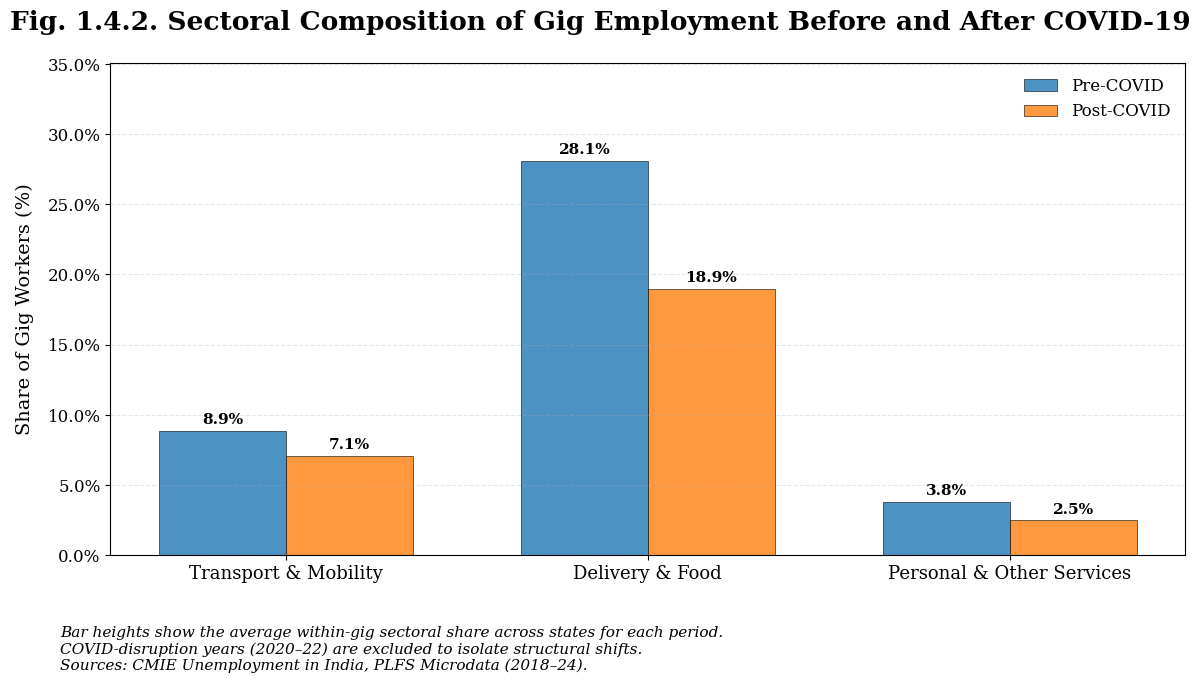

In [12]:
# ============================================================
# Visualization 2- Sectoral composition of gig work before and after COVID
# Side-by-side grouped bar chart
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams.update({"font.family": "serif"})

df = pd.read_csv("final_dataset.csv")

# ----------------------
# Period Indicator
# ----------------------
def get_period(label):
    if label in ["2018_19", "2019_20"]: return "Pre-COVID"
    if label in ["2022_23", "2023_24"]: return "Post-COVID"
    return None

df["period"] = df["year_label"].apply(get_period)
df = df.dropna(subset=["period"])

# ----------------------
# Sector Variables
# ----------------------
sector_cols = [
    "gig_transport_share_within_gig",
    "gig_delivery_food_share_within_gig",
    "gig_personal_other_share_within_gig"
]
sector_names = [
    "Transport & Mobility",
    "Delivery & Food",
    "Personal & Other Services"
]

colors = {"Pre-COVID": "#1f77b4", "Post-COVID": "#ff7f0e"}

# ----------------------
# Compute Averages
# ----------------------
sector_means = (
    df.groupby("period")[sector_cols]
      .mean()
      .rename(columns=dict(zip(sector_cols, sector_names)))
)
sector_means = sector_means.loc[["Pre-COVID", "Post-COVID"]]

# transpose so sectors are on x-axis
plot_df = sector_means.T

# ----------------------
# Figure
# ----------------------
fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(plot_df))
bar_width = 0.35
offsets = [-bar_width / 2, bar_width / 2]

for i, period in enumerate(["Pre-COVID", "Post-COVID"]):
    bars = ax.bar(
        [xi + offsets[i] for xi in x],
        plot_df[period],
        width=bar_width,
        label=period,
        color=colors[period],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
    )
    # value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.003,
            f"{height:.1%}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

# ----------------------
# Axes Formatting
# ----------------------
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df.index, fontsize=13)
ax.set_ylabel("Share of Gig Workers (%)", fontsize=14, labelpad=10)
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, plot_df.values.max() * 1.25)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(fontsize=12, frameon=False)
ax.tick_params(axis="y", labelsize=12)

# ----------------------
# Titles
# ----------------------
fig.suptitle(
    "Fig. 1.4.2. Sectoral Composition of Gig Employment Before and After COVID-19",
    fontsize=19, fontweight="bold", y=0.89
)

# ----------------------
# Footnote
# ----------------------
footnote_text = (
    "Bar heights show the average within-gig sectoral share across states for each period.\n"
    "COVID-disruption years (2020–22) are excluded to isolate structural shifts.\n"
    "Sources: CMIE Unemployment in India, PLFS Microdata (2018–24)."
)
fig.text(0.05, -0.05, footnote_text, ha="left", fontsize=11, style="italic", wrap=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

Motivation- To assess whether the post-COVID expansion of gig employment was accompanied by sectoral shifts in platform-mediated work, since different gig sectors may expose workers to varying levels of labour-market vulnerability.

Economic question- Did the sectoral distribution of gig employment change after COVID, and did expansion become concentrated in sectors with distinct labour-market risks?

Interpretation- Delivery and food services remain the largest gig sector, though their share declines from 28.1% to 18.9% after COVID. Transport and mobility falls slightly (8.9% to 7.1%), while personal and other services decline (3.8% to 2.5%). These patterns suggest that gig expansion was sectorally uneven, indicating that the labour-market effects of gig growth depend not only on its scale but also on the composition of platform activities.

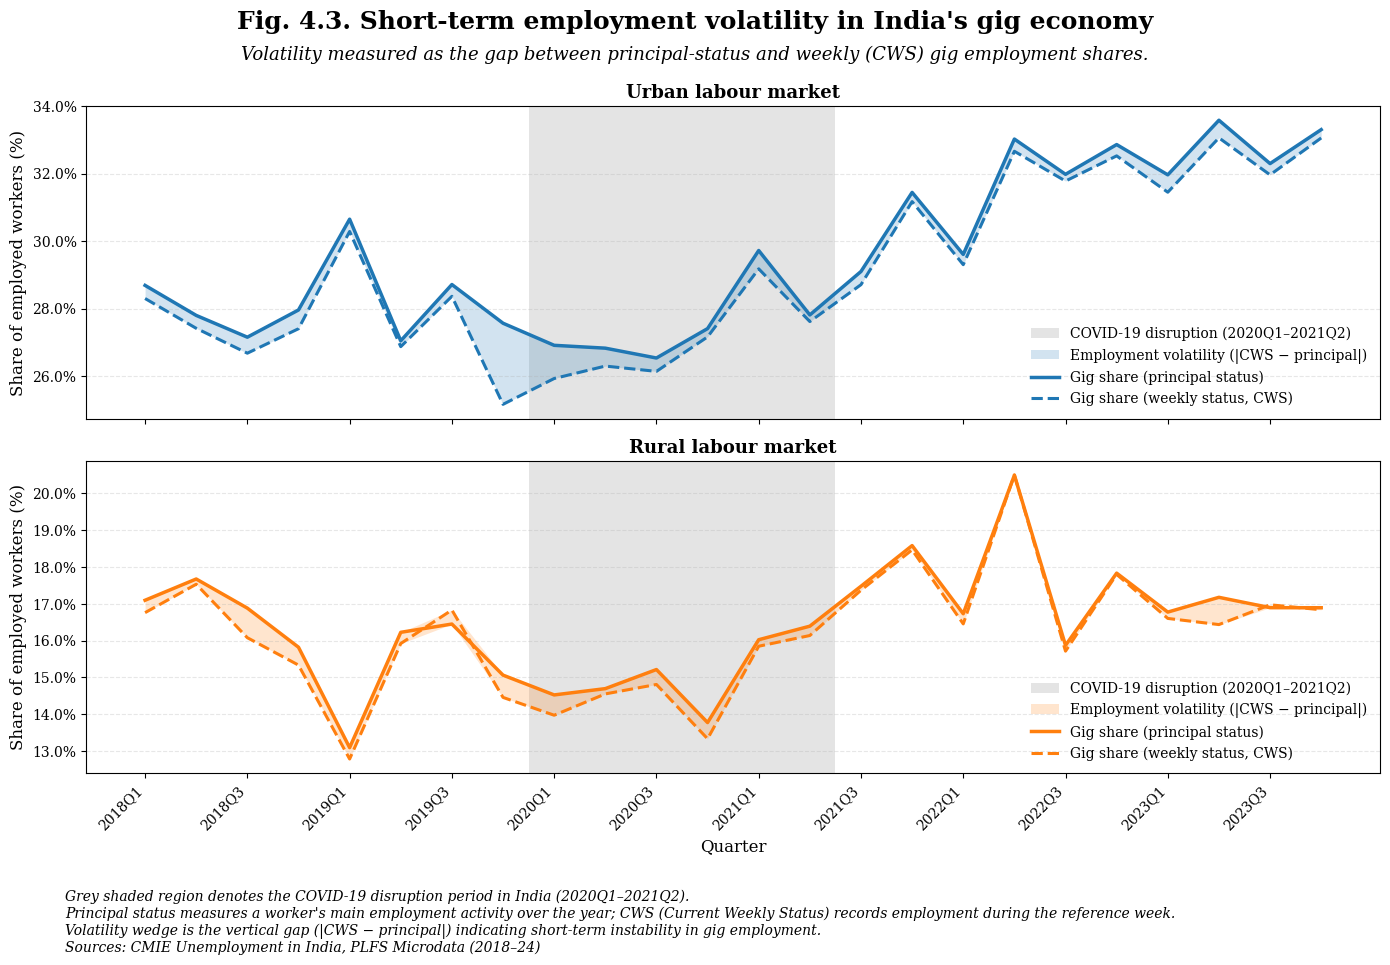

In [33]:
# Visualization 3 - Consistency Update

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ----------------------
# Typography
# ----------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

# ======================
# Build quarterly time index
# ======================
QUARTER_MAP = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4, 1: 1, 2: 2, 3: 3, 4: 4}

df["year_start"] = pd.to_numeric(df["year_label"].astype(str).str[:4], errors="coerce")
df["q_num"] = df["quarter"].map(QUARTER_MAP)
df = df.dropna(subset=["year_start", "q_num"]).copy()
df["q_num"] = df["q_num"].astype(int)

df["t_index"] = df["year_start"] * 4 + (df["q_num"] - 1)
df["t_label"] = df["year_start"].astype(str) + "Q" + df["q_num"].astype(str)

sector_map = {"rural": "Rural", "urban": "Urban", "Rural": "Rural", "Urban": "Urban"}
df["region_sector"] = df["region"].map(sector_map)

needed = ["t_index", "t_label", "region_sector", "gig_occupation_code_share", "gig_occupation_code_cws_share"]
d = df.dropna(subset=needed).copy()

ts = (
    d.groupby(["region_sector", "t_index", "t_label"], observed=False)
     .agg(
          principal=("gig_occupation_code_share", "mean"),
          cws=("gig_occupation_code_cws_share", "mean")
     )
     .reset_index()
     .sort_values(["region_sector", "t_index"])
)

# ======================
# Remap t_index to sequential positions to avoid x-axis gaps
# ======================
all_ticks = sorted(ts["t_index"].unique())
tick_to_pos = {t: i for i, t in enumerate(all_ticks)}
label_map = (
    ts.drop_duplicates("t_index")
      .sort_values("t_index")
      .set_index("t_index")["t_label"]
)
ts["pos"] = ts["t_index"].map(tick_to_pos)

# COVID shading in position space
t_start_raw = 2020 * 4 + 0  # 2020Q1
t_end_raw   = 2021 * 4 + 1  # 2021Q2
# find nearest positions just before gap and just after
pre_covid_pos  = max([tick_to_pos[t] for t in all_ticks if t <= t_start_raw], default=None)
post_covid_pos = min([tick_to_pos[t] for t in all_ticks if t >= t_end_raw],   default=None)

# ======================
# Plot settings
# ======================
COLORS = {"Urban": "#1f77b4", "Rural": "#ff7f0e"}
COVID_SHADE = "#bdbdbd"

# ======================
# Plotting
# ======================
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for region, ax in zip(["Urban", "Rural"], axes):
    sub = ts[ts["region_sector"] == region].copy().sort_values("pos")
    if sub.empty:
        continue

    lower = np.minimum(sub["principal"], sub["cws"])
    upper = np.maximum(sub["principal"], sub["cws"])

    # COVID shading using position space
    if pre_covid_pos is not None and post_covid_pos is not None:
        ax.axvspan(pre_covid_pos - 0.5, post_covid_pos + 0.5,
                   color=COVID_SHADE, alpha=0.40, lw=0,
                   label="COVID-19 disruption (2020Q1–2021Q2)")

    ax.fill_between(sub["pos"], lower, upper,
                    color=COLORS[region], alpha=0.20, linewidth=0,
                    label="Employment volatility (|CWS − principal|)")

    ax.plot(sub["pos"], sub["principal"],
            color=COLORS[region], lw=2.5, label="Gig share (principal status)")
    ax.plot(sub["pos"], sub["cws"],
            color=COLORS[region], lw=2.2, linestyle="--", label="Gig share (weekly status, CWS)")

    ax.set_title(f"{region} labour market", fontsize=13, fontweight="bold")
    ax.set_ylabel("Share of employed workers (%)", fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(frameon=False, loc="lower right", fontsize=10)

# ======================
# X-axis — evenly spaced, no gaps
# ======================
positions = list(range(len(all_ticks)))
labels    = [label_map[t] for t in all_ticks]
step = max(1, len(positions) // 10)
axes[-1].set_xticks(positions[::step])
axes[-1].set_xticklabels(labels[::step], rotation=45, ha="right", fontsize=10)
axes[-1].set_xlabel("Quarter", fontsize=12)

# ======================
# Titles & Footnote
# ======================
fig.suptitle(
    "Fig. 4.3. Short-term employment volatility in India's gig economy",
    fontsize=18, fontweight="bold", y=0.92
)
fig.text(
    0.5, 0.87,
    "Volatility measured as the gap between principal-status and weekly (CWS) gig employment shares.",
    ha="center", fontsize=13, style="italic"
)

footnote_text = (
    "Grey shaded region denotes the COVID-19 disruption period in India (2020Q1–2021Q2).\n"
    "Principal status measures a worker's main employment activity over the year; "
    "CWS (Current Weekly Status) records employment during the reference week.\n"
    "Volatility wedge is the vertical gap (|CWS − principal|) indicating short-term instability in gig employment.\n"
    "Sources: CMIE Unemployment in India, PLFS Microdata (2018–24)"
)
fig.text(0.05, -0.02, footnote_text, ha="left", fontsize=10, style="italic", wrap=True)

plt.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()

Motivation- The volatility wedge is constructed to capture short-term instability in gig participation that may reflect episodic engagement and weak employment protection.

Economic question- Did COVID generate a volatility shock in gig employment, and did this dynamic differ between urban and rural labour markets?

Interpretation- The wedge widens during COVID and narrows thereafter, indicating a temporary spike in instability rather than persistent volatility. Urban labour markets maintain higher gig shares with smaller wedges, suggesting more stable integration of gig work. Rural markets show lower participation but greater variation, consistent with thinner labour markets and irregular engagement. Overall, COVID generated a short-lived volatility shock while gig participation remained elevated without clear improvements in employment stability.

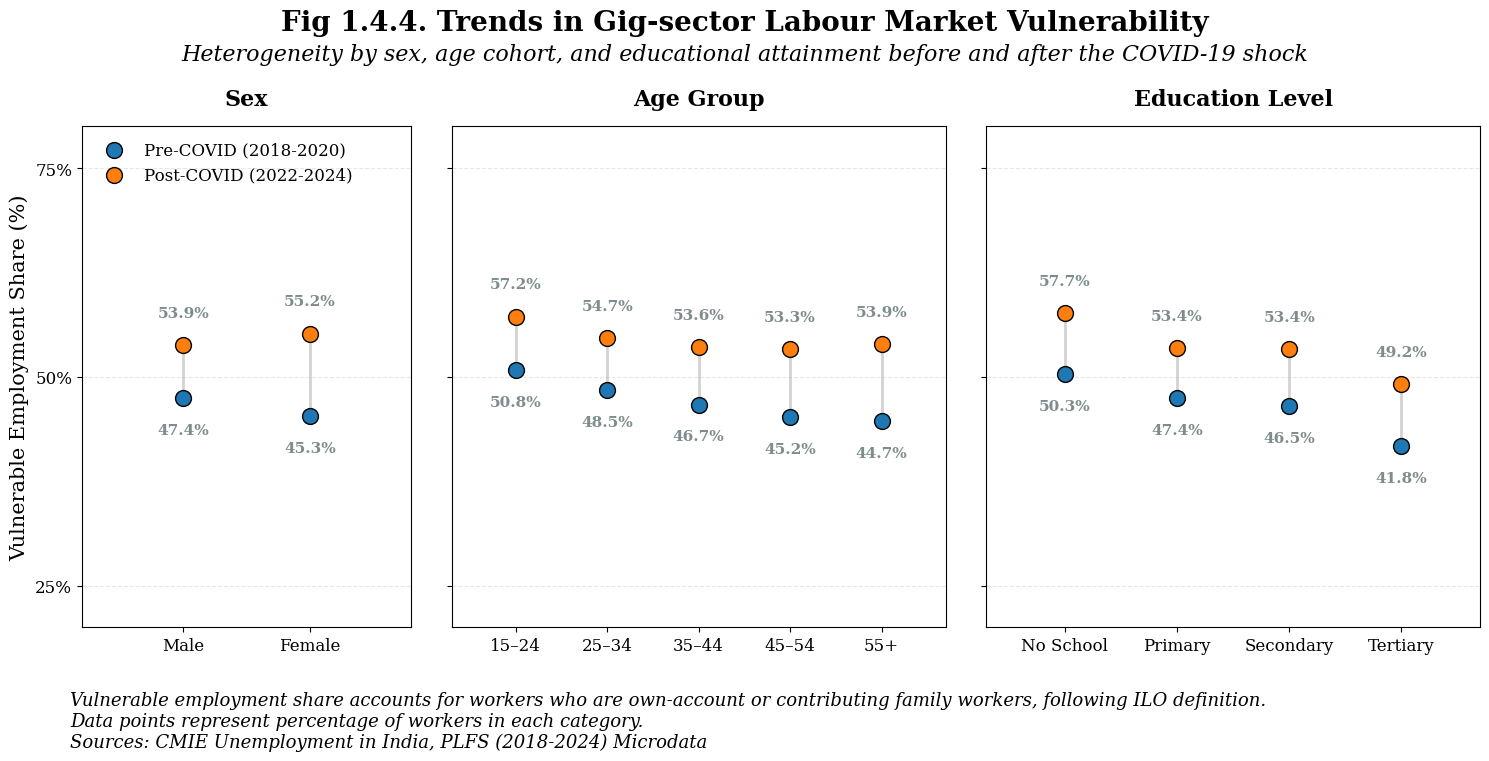

In [16]:
# Visualization 4 - Standardized Demographic Analysis
# ----------------------
# Typography: Serif Fallback
# ----------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 13, 
    "axes.labelsize": 13,
})

# 1. Define Categories and Metrics
v_col = "vulnerable_employment_share"
weight_col = "gig_employed_weighted"

groups = {
    "Sex": {"Male": "gig_male_share_within_gig", "Female": "gig_female_share_within_gig"},
    "Age Group": {
        "15–24": "gig_age_15_24_share_within_gig", "25–34": "gig_age_25_34_share_within_gig",
        "35–44": "gig_age_35_44_share_within_gig", "45–54": "gig_age_45_54_share_within_gig",
        "55+": "gig_age_55p_share_within_gig"
    },
    "Education Level": {
        "No School": "gig_edu_no_schooling_share_within_gig", "Primary": "gig_edu_primary_share_within_gig",
        "Secondary": "gig_edu_secondary_share_within_gig", "Tertiary": "gig_edu_tertiary_share_within_gig"
    }
}

# 2. Period Mapping & Cleaning
def get_period(label):
    if label in ["2018_19", "2019_20"]: return "Pre-COVID"
    if label in ["2022_23", "2023_24"]: return "Post-COVID"
    return None

df['period'] = df['year_label'].apply(get_period)
for section in groups.values():
    for col in section.values():
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 7.5), sharey=True, gridspec_kw={'width_ratios': [1.5, 2.25, 2.25]})

# Updated color scheme: Blue for Pre-COVID, Orange for Post-COVID
color_pre, color_post = "#1f77b4", "#ff7f0e" 
line_color = "#d3d3d3" # Lighter grey for the connecting line to let markers pop

for i, section in enumerate(groups.keys()):
    ax = axes[i]
    categories = list(groups[section].keys())
    
    # ADJUSTED: Added consistent padding to all plots to move points away from the Y-axis
    if section == "Sex": 
        ax.set_xlim(-0.8, 1.8) # Widened from -0.6/1.6
    elif section == "Age Group":
        ax.set_xlim(-0.7, len(categories) - 0.3) # Shifts the age points right
    else: # Education Level
        ax.set_xlim(-0.7, len(categories) - 0.3) # Shifts the education points right

    for j, cat in enumerate(categories):
        col_name = groups[section][cat]
        vals = []
        for period in ["Pre-COVID", "Post-COVID"]:
            sub = df[df['period'] == period].dropna(subset=[v_col, weight_col, col_name])
            weight = sub[weight_col] * sub[col_name]
            vals.append((sub[v_col] * weight).sum() / weight.sum())
        
        pre_val, post_val = vals[0], vals[1]
        
        ax.plot([j, j], [pre_val, post_val], color=line_color, lw=2, zorder=1)
        ax.scatter(j, pre_val, color=color_pre, s=130, edgecolors='black', label='Pre-COVID (2018-2020)' if i==0 and j==0 else "", zorder=3)
        ax.scatter(j, post_val, color=color_post, s=130, edgecolors='black', label='Post-COVID (2022-2024)' if i==0 and j==0 else "", zorder=3)
        
        ax.text(j, pre_val - 0.03, f"{pre_val:.1%}", ha='center', va='top', fontsize=11, color='#7f8c8d', fontweight='bold', clip_on=False)
        ax.text(j, post_val + 0.03, f"{post_val:.1%}", ha='center', va='bottom', fontsize=11, color='#7f8c8d', fontweight='bold', clip_on=False)

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=0, fontsize=12)
    ax.set_title(section, fontsize=16, fontweight='bold', pad=15)
    
    ax.set_ylim(0.2, 0.8) 
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.25))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='y', labelsize=12)

    if i == 0:
        ax.set_ylabel("Vulnerable Employment Share (%)", fontsize=15)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.legend(frameon=False, loc='upper left', fontsize=12)

# ======================
# Titles & Footnotes
# ======================
fig.suptitle("Fig 1.4.4. Trends in Gig-sector Labour Market Vulnerability", 
             fontsize=20, fontweight='bold', y=0.96) # Main heading size 15
fig.text(
    0.5, 0.915,
    "Heterogeneity by sex, age cohort, and educational attainment before and after the COVID-19 shock",
    ha="center", va="top", fontsize=16, style='italic'
)

footnote_text = (
    "Vulnerable employment share accounts for workers who are own-account or contributing family workers, following ILO definition.\n"    "Data points represent percentage of workers in each category.\n"
    "Sources: CMIE Unemployment in India, PLFS (2018-2024) Microdata"
)
fig.text(0.05, - 0.02, footnote_text, ha="left", fontsize=13, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

Motivation- Stratifying by sex, age, and education tests heterogeneity in gig vulnerability along margins linked to sorting, bargaining power, and access to protected work.

Economic question- How did COVID shift vulnerability within gig work across demographic groups, and what does this imply about Z?

Interpretation- Vulnerable employment rises post-COVID across all groups, indicating that gig expansion coincided with higher vulnerability rather than improved job quality. Even tertiary-educated gig workers experience increases (≈41.8% to 49.2%), suggesting precariousness reflects the contractual structure of gig work rather than skill alone. Younger workers remain more vulnerable, and vulnerability rises for both men and women. Overall, gig expansion affected diverse worker groups while protection gaps remained unchanged.

#2. Project Two

##2.1 The Message

States with higher gig employment exposure tend to exhibit higher vulnerable employment. However, gig precarity varies substantially across states with similar exposure, suggesting that the labour-market effects of gig expansion depend on the structural quality of gig work, not exposure alone.

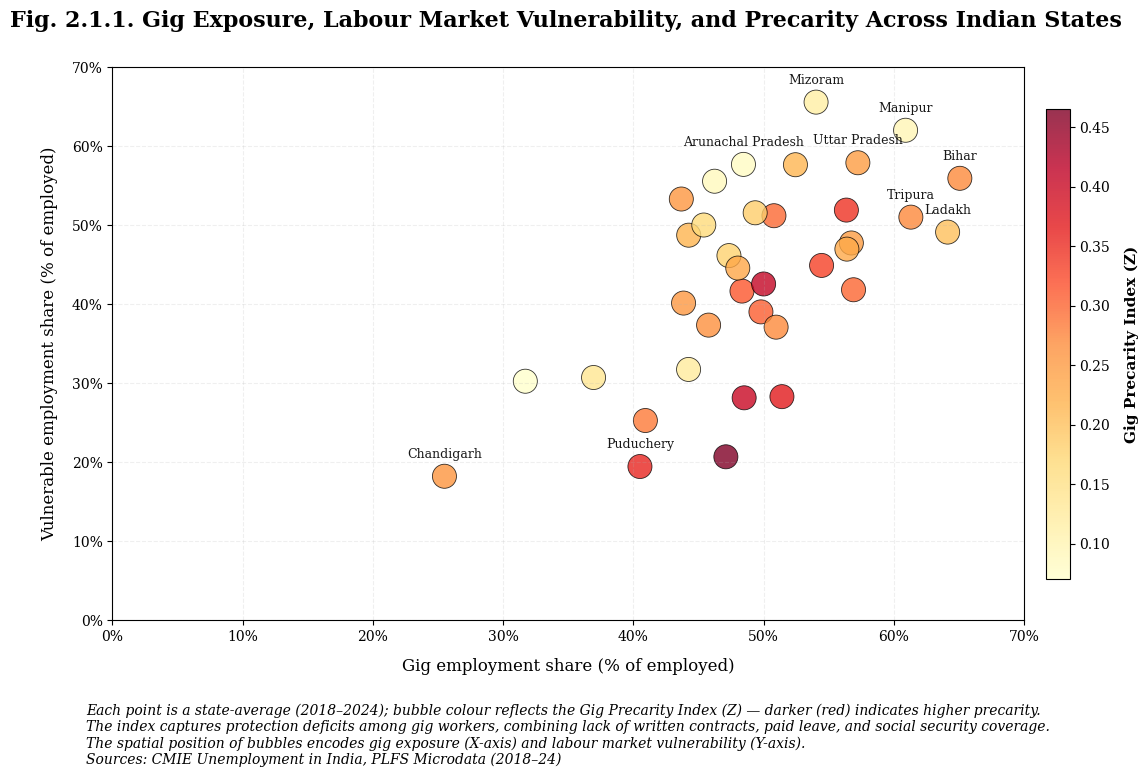

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import Normalize

# ----------------------
# Typography
# ----------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

# ----------------------
# Data Preparation
# ----------------------
X_exposure = "gig_employment_share_principal"
Z_precarity = "gig_precarity_index"

needed = ["state", "vulnerable_employment_share", Z_precarity, X_exposure]
d = df.dropna(subset=needed).copy()

state_avg = (
    d.groupby("state", observed=False)[
        ["vulnerable_employment_share", Z_precarity, X_exposure]
    ]
    .mean()
    .reset_index()
)

# Bubble size — fixed moderate size, discernible but not dominant
state_avg['bubble_size'] = 300

# ----------------------
# Plotting
# ----------------------
fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.cm.YlOrRd  # low precarity = yellow, high = red
norm = Normalize(vmin=state_avg[Z_precarity].min(), vmax=state_avg[Z_precarity].max())

sc = ax.scatter(
    state_avg[X_exposure],
    state_avg["vulnerable_employment_share"],
    s=state_avg["bubble_size"],
    c=state_avg[Z_precarity],
    cmap=cmap,
    norm=norm,
    alpha=0.80,
    edgecolor="black",
    linewidth=0.6,
)

# ----------------------
# Colorbar
# ----------------------
cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label("Gig Precarity Index (Z)", fontsize=11, fontweight="bold", labelpad=10)
cbar.ax.tick_params(labelsize=10)

# ----------------------
# Axes Formatting
# ----------------------
ax.set_xlabel("Gig employment share (% of employed)", labelpad=10)
ax.set_ylabel("Vulnerable employment share (% of employed)", labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_locator(MultipleLocator(0.10))
ax.yaxis.set_major_locator(MultipleLocator(0.10))
ax.set_xlim(left=0, right=0.7)
ax.set_ylim(bottom=0, top=0.7)
ax.grid(alpha=0.2, linestyle="--")

# ----------------------
# Titles
# ----------------------
fig.suptitle(
    "Fig. 2.1.1. Gig Exposure, Labour Market Vulnerability, and Precarity Across Indian States",
    fontsize=16,
    fontweight="bold", x=0.45,
    y=0.93
)

# ----------------------
# State Labels
# ----------------------
x_hi = state_avg[X_exposure].quantile(0.9)
x_lo = state_avg[X_exposure].quantile(0.1)
y_hi = state_avg["vulnerable_employment_share"].quantile(0.9)
y_lo = state_avg["vulnerable_employment_share"].quantile(0.1)

for _, r in state_avg.iterrows():
    if r[X_exposure] > x_hi or r["vulnerable_employment_share"] > y_hi or \
       (r[X_exposure] < x_lo and r["vulnerable_employment_share"] < y_lo):
        ax.text(
            r[X_exposure],
            r["vulnerable_employment_share"] + 0.02,
            r["state"],
            fontsize=9,
            ha='center',
            va='bottom',
            alpha=0.9
        )

# ----------------------
# Footnote
# ----------------------
footnote_text = (
    "Each point is a state-average (2018–2024); bubble colour reflects the Gig Precarity Index (Z) — darker (red) indicates higher precarity.\n"
    "The index captures protection deficits among gig workers, combining lack of written contracts, paid leave, and social security coverage.\n"
    "The spatial position of bubbles encodes gig exposure (X-axis) and labour market vulnerability (Y-axis).\n"
    "Sources: CMIE Unemployment in India, PLFS Microdata (2018–24)"
)

fig.text(0.05, -0.01, footnote_text, ha="left", fontsize=10, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

Fig 2.1.1 is a state-level scatter plot shows gig employment exposure (X) on the x-axis and vulnerable employment (Y) on the y-axis, with each point representing a state average. Colour denotes the Gig Precarity Index (Z), where darker tones indicate weaker protections. The positive X–Y association with substantial variation in Z among similarly exposed states suggests that gig exposure alone does not determine vulnerability, motivating analysis of the interaction between exposure and precarity.

##2.2 Maps and Interpretations

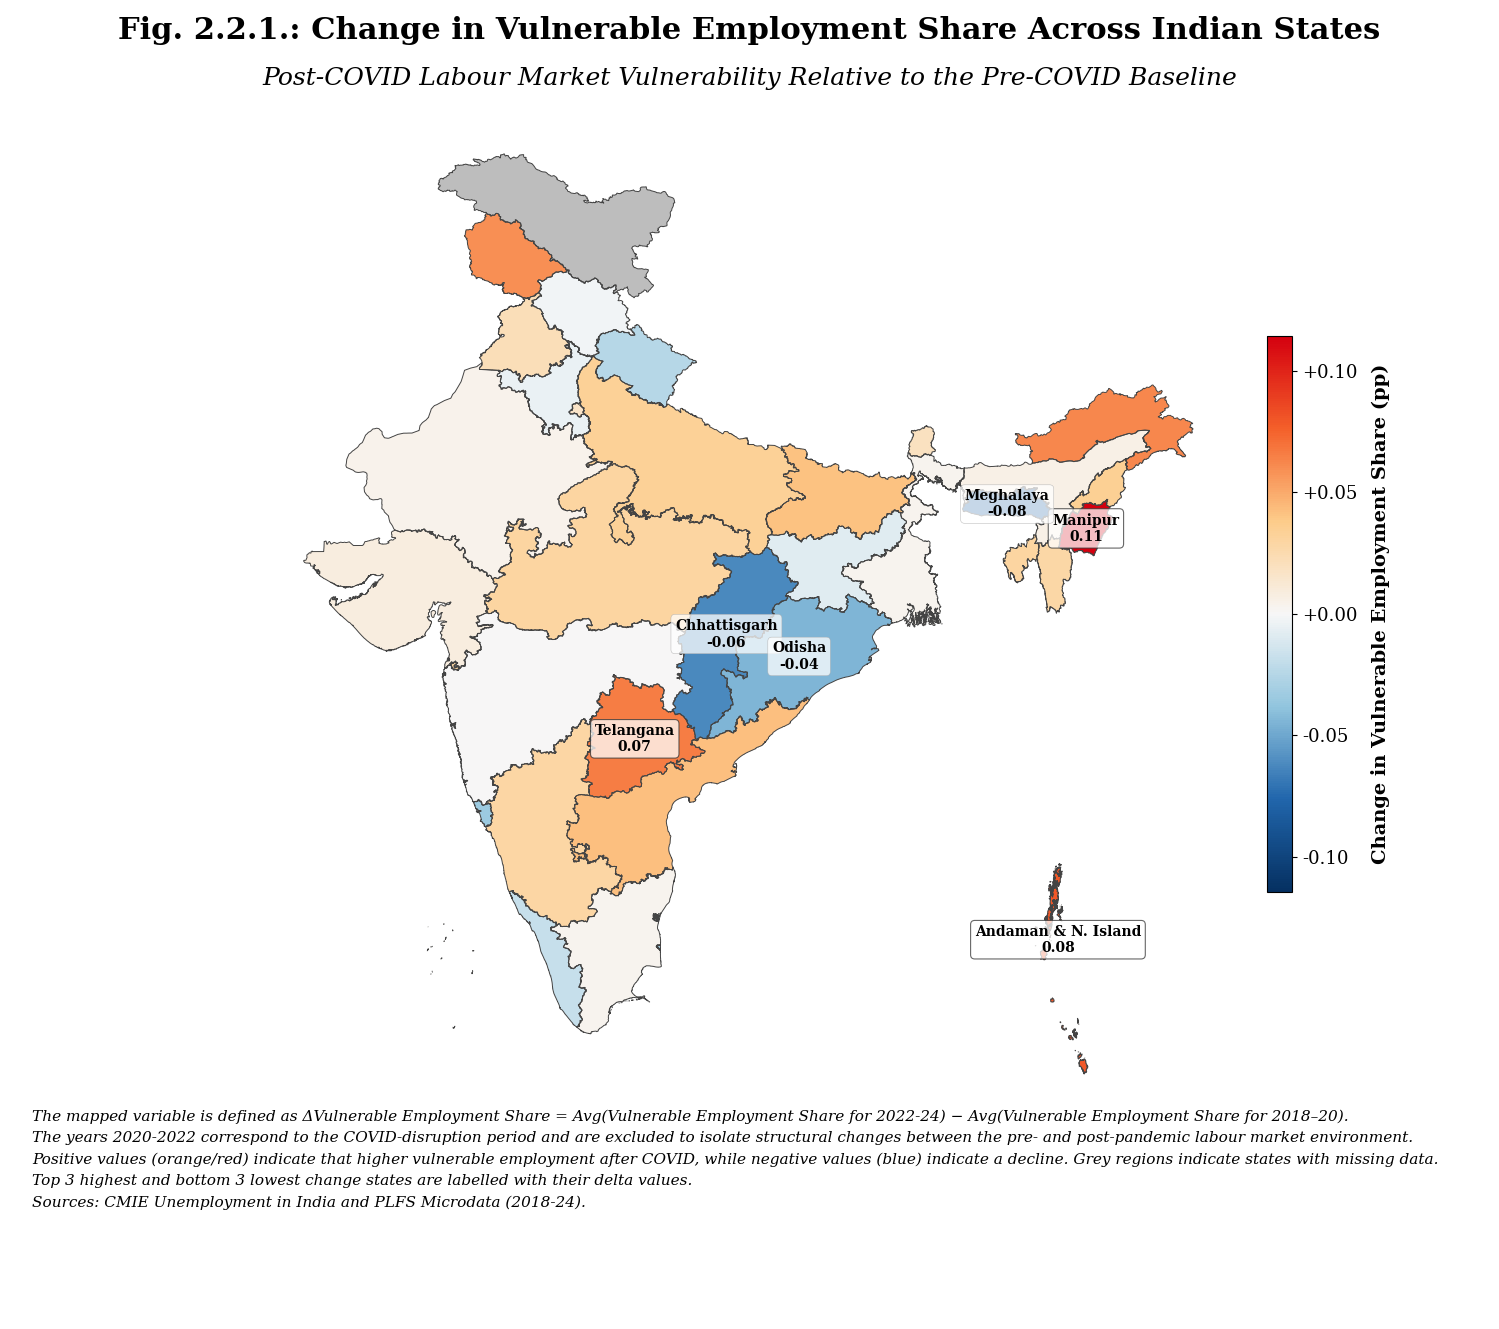

In [18]:
# ============================================================
# MAP: CHANGE IN VULNERABLE EMPLOYMENT SHARE (Y)
# Post-COVID average (2022-2024) minus Pre-COVID average (2018-2020)
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np

plt.rcParams.update({"font.family": "serif"})

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("final_dataset.csv")

# ------------------------------------------------------------
# 1. CUSTOM ORANGE-BLUE DIVERGING COLORMAP
# ------------------------------------------------------------
colors_blue_to_orange = [
    "#053061",   # deep navy blue  — largest decrease
    "#2166AC",   # strong blue
    "#92C5DE",   # light blue
    "#F7F7F7",   # neutral white — zero change
    "#FDCC8A",   # light orange
    "#F4602A",   # vivid orange-red
    "#D4000F",   # deep red-orange — largest increase
]
cmap_bo = LinearSegmentedColormap.from_list("BlueOrange", colors_blue_to_orange, N=256)

# ------------------------------------------------------------
# 2. HELPER FUNCTION: WEIGHTED AVERAGE
# ------------------------------------------------------------
def wavg(g, value_col="vulnerable_employment_share", weight_col="employed_weighted"):
    x = pd.to_numeric(g[value_col], errors="coerce")
    w = pd.to_numeric(g[weight_col], errors="coerce")
    mask = x.notna() & w.notna() & (w > 0)
    return np.average(x[mask], weights=w[mask]) if mask.any() else np.nan

# ------------------------------------------------------------
# 3. PREPARE Y VARIABLE
# ------------------------------------------------------------
df["Y"] = pd.to_numeric(df["vulnerable_employment_share"], errors="coerce")

pre_years  = ["2018_19", "2019_20"]
post_years = ["2022_23", "2023_24"]

# ------------------------------------------------------------
# 4. STATE-LEVEL PRE AND POST AVERAGES (FutureWarning-safe)
# ------------------------------------------------------------
def state_wavg(sub_df, out_col):
    return (
        sub_df.groupby("state", as_index=False)
        .apply(
            lambda g: pd.Series({out_col: wavg(g, value_col="Y", weight_col="employed_weighted")}),
            include_groups=False
        )
        .reset_index(drop=True)
    )

df_pre  = state_wavg(df[df["year_label"].isin(pre_years)],  "Y_pre")
df_post = state_wavg(df[df["year_label"].isin(post_years)], "Y_post")

df_change = df_pre.merge(df_post, on="state", how="outer")
df_change["delta_vulnerable"] = df_change["Y_post"] - df_change["Y_pre"]

# ------------------------------------------------------------
# 5. LOAD AND CLEAN INDIA SHAPEFILE
# ------------------------------------------------------------
india_states_url = (
    "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/"
    "releaseData/gbOpen/IND/ADM1/geoBoundaries-IND-ADM1.geojson"
)
india_states = gpd.read_file(india_states_url)

state_name_fixes = {
    "Tamil Nādu": "Tamilnadu",
    "Jammu and Kashmīr": "Jammu & Kashmir",
    "Ladākh": "Ladakh",
    "Puducherry": "Puduchery",
    "Andaman and Nicobar Islands": "Andaman & N. Island",
    "Dādra and Nagar Haveli and Damān and Diu": "D & N. Haveli & Daman & Diu",
    "Mahārāshtra": "Maharashtra",
    "Chhattīsgarh": "Chhattisgarh",
    "Gujarāt": "Gujarat",
    "Bihār": "Bihar",
    "Rājasthān": "Rajasthan",
    "Telangāna": "Telangana",
    "Karnātaka": "Karnataka",
    "Jhārkhand": "Jharkhand",
    "Haryāna": "Haryana",
    "Uttarākhand": "Uttarakhand",
    "Himāchal Pradesh": "Himachal Pradesh",
    "Arunāchal Pradesh": "Arunachal Pradesh",
    "Meghālaya": "Meghalaya",
    "Nāgāland": "Nagaland",
}
india_states["shapeName"] = india_states["shapeName"].replace(state_name_fixes)

map_df = india_states.merge(
    df_change, left_on="shapeName", right_on="state", how="left"
)

# ------------------------------------------------------------
# 6. SYMMETRIC DIVERGING SCALE
# ------------------------------------------------------------
max_abs = np.nanmax(np.abs(map_df["delta_vulnerable"]))

# ------------------------------------------------------------
# 7. TOP / BOTTOM LABEL STATES
# ------------------------------------------------------------
top3    = map_df.nlargest(3,  "delta_vulnerable")
bottom3 = map_df.nsmallest(3, "delta_vulnerable")
outliers = pd.concat([top3, bottom3]).drop_duplicates(subset=["shapeName"])

outliers_proj = outliers.to_crs("EPSG:32644")
centroids     = outliers_proj.geometry.centroid.to_crs("EPSG:4326")

# ------------------------------------------------------------
# 8. FIGURE LAYOUT
# ------------------------------------------------------------
fig = plt.figure(figsize=(17, 17))
fig.subplots_adjust(left=0.1, right=0.97)  

gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[0.08, 1, 0.18],
    hspace=0.04,
    figure=fig,
)

title_ax    = fig.add_subplot(gs[0])
ax          = fig.add_subplot(gs[1])
footnote_ax = fig.add_subplot(gs[2])

for a in (title_ax, footnote_ax):
    a.set_axis_off()
    
# ------------------------------------------------------------
# 9. TITLES
# ------------------------------------------------------------
title_ax.text(
    0.5, 0.75,
    "Fig. 2.2.1.: Change in Vulnerable Employment Share Across Indian States",
    transform=title_ax.transAxes, ha="center", va="center",
    fontsize=22, fontweight="bold",
)
title_ax.text(
    0.5, 0.15,
    "Post-COVID Labour Market Vulnerability Relative to the Pre-COVID Baseline",
    transform=title_ax.transAxes, ha="center", va="center",
    fontsize=18, style="italic",
)

# ------------------------------------------------------------
# 10. MAP
# ------------------------------------------------------------
map_df.boundary.plot(ax=ax, linewidth=0.7, color="#444444", zorder=2)

map_df.plot(
    ax=ax,
    column="delta_vulnerable",
    cmap=cmap_bo,
    vmin=-max_abs,
    vmax= max_abs,
    legend=True,
    missing_kwds={"color": "#BDBDBD","label": "No Data"}, 
    legend_kwds={
        "orientation": "vertical",
        "shrink": 0.55,
        "aspect": 22,
        "pad": 0.02,
        "format": "%.2f",
    },
    zorder=1,
)

# ── State labels───────
for centroid, (_, row) in zip(centroids, outliers.iterrows()):
    is_top = row["shapeName"] in top3["shapeName"].values
    ax.annotate(
        f"{row['shapeName']}\n{row['delta_vulnerable']:.2f}",
        xy=(centroid.x, centroid.y),
        fontsize=10, ha="center", va="center",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.75,
            edgecolor="#333333" if is_top else "#aaaaaa",
            linewidth=0.8 if is_top else 0.4,
        ),
    )

ax.set_axis_off()
ax.set_aspect("equal")

# Style the colorbar
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel(
    "Change in Vulnerable Employment Share (pp)",
    size=14, weight="bold", labelpad=10,
)
cbar_ax.tick_params(labelsize=13)  # increase from 10 → 13

# Force explicit +/- signs and larger font on tick labels
cbar_ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:+.2f}")
)

# ------------------------------------------------------------
# 11. FOOTNOTE
# ------------------------------------------------------------
footnote_text = (
    "The mapped variable is defined as ΔVulnerable Employment Share = Avg(Vulnerable Employment Share for 2022-24) − Avg(Vulnerable Employment Share for 2018–20).\n"
    "The years 2020-2022 correspond to the COVID-disruption period and are excluded "
    "to isolate structural changes between the pre- and post-pandemic labour market environment.\n"
    "Positive values (orange/red) indicate that higher vulnerable employment after COVID, while negative values (blue) indicate a decline. Grey regions indicate states with missing data.\n"
    "Top 3 highest and bottom 3 lowest change states are labelled with their delta values.\n"
    "Sources: CMIE Unemployment in India and PLFS Microdata (2018-24)."
)

footnote_ax.text(
    0.015, 1.15, footnote_text,
    transform=footnote_ax.transAxes, ha="left", va="top",
    fontsize=11, linespacing=1.65, style="italic")

plt.show()

Fig 2.2.1 shows state-level changes in vulnerable employment, measured as the difference between the 2022–2024 average and the pre-COVID baseline. The figure reveals substantial spatial heterogeneity: vulnerability rises most in Manipur and Telangana, while Chhattisgarh and Odisha decline. The uneven pattern suggests recovery did not uniformly improve employment security and may reflect shifts toward gig-type employment, motivating analysis of whether cross-state variation in gig expansion explains these changes.

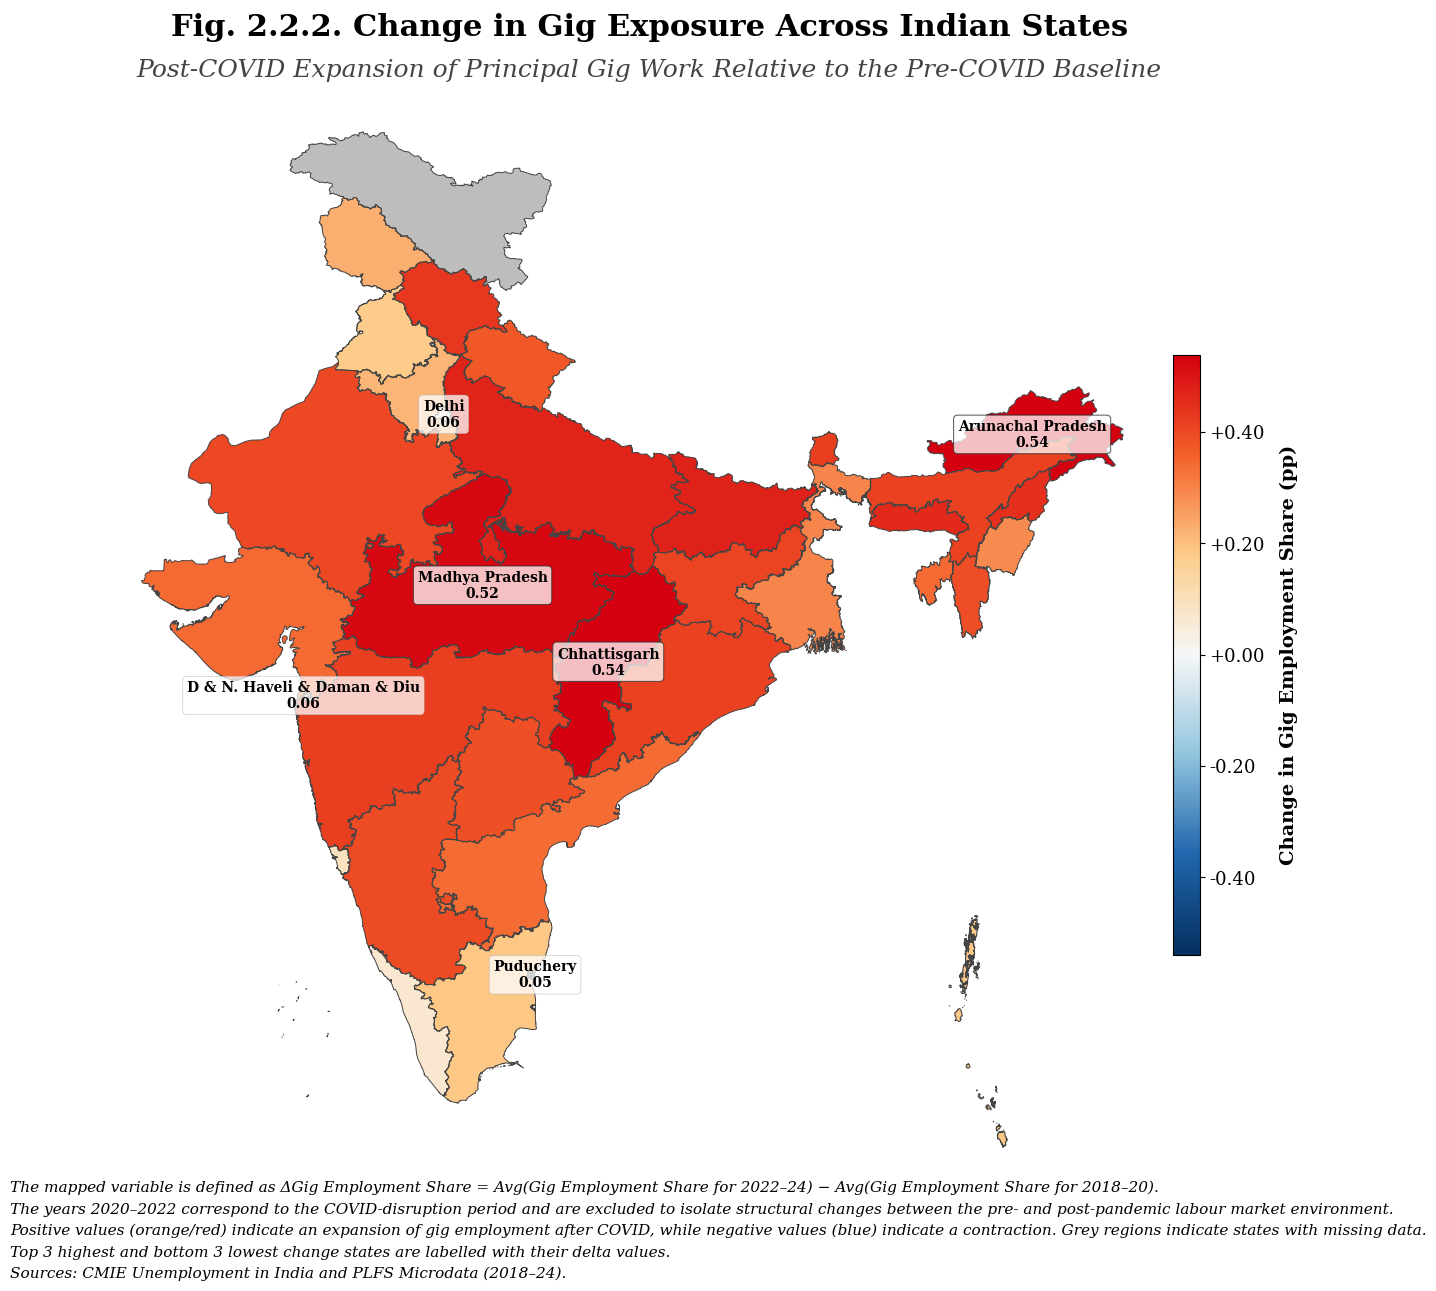

In [20]:
# ============================================================
# MAP: CHANGE IN GIG EXPOSURE (X)
# Post-COVID average (2022-2024) minus Pre-COVID average (2018-2020)
# Excluding main COVID-disruption years
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np

plt.rcParams.update({"font.family": "serif"})

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("final_dataset.csv")

# ------------------------------------------------------------
# 1. CUSTOM ORANGE-BLUE DIVERGING COLORMAP
# ------------------------------------------------------------
colors_blue_to_orange = [
    "#053061",   # deep navy blue  — largest decrease
    "#2166AC",   # strong blue
    "#92C5DE",   # light blue
    "#F7F7F7",   # neutral white — zero change
    "#FDCC8A",   # light orange
    "#F4602A",   # vivid orange-red
    "#D4000F",   # deep red-orange — largest increase
]
cmap_bo = LinearSegmentedColormap.from_list("BlueOrange", colors_blue_to_orange, N=256)

# ------------------------------------------------------------
# 2. HELPER FUNCTION: WEIGHTED AVERAGE
# ------------------------------------------------------------
def wavg(g, value_col, weight_col="employed_weighted"):
    x = pd.to_numeric(g[value_col], errors="coerce")
    w = pd.to_numeric(g[weight_col], errors="coerce")
    mask = x.notna() & w.notna() & (w > 0)
    return np.average(x[mask], weights=w[mask]) if mask.any() else np.nan

# ------------------------------------------------------------
# 3. PREPARE X VARIABLE
# ------------------------------------------------------------
df["X"] = pd.to_numeric(df["gig_employment_share_principal"], errors="coerce")

pre_years  = ["2018_19", "2019_20"]
post_years = ["2022_23", "2023_24"]

# ------------------------------------------------------------
# 4. STATE-LEVEL PRE AND POST AVERAGES (FutureWarning-safe)
# ------------------------------------------------------------
def state_wavg(sub_df, out_col):
    return (
        sub_df.groupby("state", as_index=False)
        .apply(
            lambda g: pd.Series({out_col: wavg(g, value_col="X", weight_col="employed_weighted")}),
            include_groups=False
        )
        .reset_index(drop=True)
    )

df_pre  = state_wavg(df[df["year_label"].isin(pre_years)],  "X_pre")
df_post = state_wavg(df[df["year_label"].isin(post_years)], "X_post")

df_change = df_pre.merge(df_post, on="state", how="outer")
df_change["delta_gig_exposure"] = df_change["X_post"] - df_change["X_pre"]

# ------------------------------------------------------------
# 5. LOAD AND CLEAN INDIA SHAPEFILE
# ------------------------------------------------------------
india_states_url = (
    "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/"
    "releaseData/gbOpen/IND/ADM1/geoBoundaries-IND-ADM1.geojson"
)
india_states = gpd.read_file(india_states_url)

state_name_fixes = {
    "Tamil Nādu": "Tamilnadu",
    "Jammu and Kashmīr": "Jammu & Kashmir",
    "Ladākh": "Ladakh",
    "Puducherry": "Puduchery",
    "Andaman and Nicobar Islands": "Andaman & N. Island",
    "Dādra and Nagar Haveli and Damān and Diu": "D & N. Haveli & Daman & Diu",
    "Mahārāshtra": "Maharashtra",
    "Chhattīsgarh": "Chhattisgarh",
    "Gujarāt": "Gujarat",
    "Bihār": "Bihar",
    "Rājasthān": "Rajasthan",
    "Telangāna": "Telangana",
    "Karnātaka": "Karnataka",
    "Jhārkhand": "Jharkhand",
    "Haryāna": "Haryana",
    "Uttarākhand": "Uttarakhand",
    "Himāchal Pradesh": "Himachal Pradesh",
    "Arunāchal Pradesh": "Arunachal Pradesh",
    "Meghālaya": "Meghalaya",
    "Nāgāland": "Nagaland",
}
india_states["shapeName"] = india_states["shapeName"].replace(state_name_fixes)

map_df = india_states.merge(
    df_change, left_on="shapeName", right_on="state", how="left"
)

# ------------------------------------------------------------
# 6. SYMMETRIC DIVERGING SCALE
# ------------------------------------------------------------
max_abs = np.nanmax(np.abs(map_df["delta_gig_exposure"]))

# ------------------------------------------------------------
# 7. TOP / BOTTOM LABEL STATES
# ------------------------------------------------------------
top3    = map_df.nlargest(3,  "delta_gig_exposure")
bottom3 = map_df.nsmallest(3, "delta_gig_exposure")
outliers = pd.concat([top3, bottom3]).drop_duplicates(subset=["shapeName"])

outliers_proj = outliers.to_crs("EPSG:32644")
centroids     = outliers_proj.geometry.centroid.to_crs("EPSG:4326")

# ------------------------------------------------------------
# 8. FIGURE LAYOUT
# ------------------------------------------------------------
fig = plt.figure(figsize=(15, 15))

gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[0.08, 1, 0.18],
    hspace=0.04,
    figure=fig,
)

title_ax    = fig.add_subplot(gs[0])
ax          = fig.add_subplot(gs[1])
footnote_ax = fig.add_subplot(gs[2])

for a in (title_ax, footnote_ax):
    a.set_axis_off()

# ------------------------------------------------------------
# 9. TITLES
# ------------------------------------------------------------
title_ax.text(
    0.55, 0.75,
    "Fig. 2.2.2. Change in Gig Exposure Across Indian States",
    transform=title_ax.transAxes, ha="center", va="center",
    fontsize=22, fontweight="bold",
)
title_ax.text(
    0.55, 0.15,
    "Post-COVID Expansion of Principal Gig Work Relative to the Pre-COVID Baseline",
    transform=title_ax.transAxes, ha="center", va="center",
    fontsize=18, style="italic", color="#444444",
)

# ------------------------------------------------------------
# 10. MAP
# ------------------------------------------------------------
map_df.boundary.plot(ax=ax, linewidth=0.7, color="#444444", zorder=2)

map_df.plot(
    ax=ax,
    column="delta_gig_exposure",
    cmap=cmap_bo,
    vmin=-max_abs,
    vmax= max_abs,
    legend=True,
    missing_kwds={"color": "#BDBDBD", "label": "No Data"},
    legend_kwds={
        "orientation": "vertical",
        "shrink": 0.55,
        "aspect": 22,
        "pad": 0.02,
        "format": "%.2f",
    },
    zorder=1,
)

# ── State labels ─────────────────────────────────────────────
for centroid, (_, row) in zip(centroids, outliers.iterrows()):
    is_top = row["shapeName"] in top3["shapeName"].values
    ax.annotate(
        f"{row['shapeName']}\n{row['delta_gig_exposure']:.2f}",
        xy=(centroid.x, centroid.y),
        fontsize=10, ha="center", va="center",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.75,
            edgecolor="#333333" if is_top else "#aaaaaa",
            linewidth=0.8 if is_top else 0.4,
        ),
    )

ax.set_axis_off()
ax.set_aspect("equal")


# Reposition map axes directly: [left, bottom, width, height]
ax.set_position([0.18, 0.07, 0.72, 0.78])  
# Style the colorbar
cbar_ax = fig.axes[-1]
cbar_ax.set_position([0.9, 0.25, 0.03, 0.4])  # [left, bottom, width, height]
cbar_ax.set_ylabel(
    "Change in Gig Employment Share (pp)",
    size=14, weight="bold", labelpad=10,
)
cbar_ax.tick_params(labelsize=13) 

# Force explicit +/- signs and larger font on tick labels
cbar_ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:+.2f}")
)

# ------------------------------------------------------------
# 11. FOOTNOTE
# ------------------------------------------------------------
footnote_text = (
    "The mapped variable is defined as ΔGig Employment Share = "
    "Avg(Gig Employment Share for 2022–24) − Avg(Gig Employment Share for 2018–20).\n"
    "The years 2020–2022 correspond to the COVID-disruption "
    "period and are excluded to isolate structural changes between the pre- and post-pandemic labour market environment.\n"
    "Positive values (orange/red) indicate an expansion of gig employment after COVID, while negative values (blue) indicate a contraction. "
    "Grey regions indicate states with missing data.\n"
    "Top 3 highest and bottom 3 lowest change states are labelled with their delta values.\n"
    "Sources: CMIE Unemployment in India and PLFS Microdata (2018–24)."
)

footnote_ax.text(
    0.0, -0.1, footnote_text,
    transform=footnote_ax.transAxes, ha="left", va="top",
    fontsize=11, linespacing=1.65, style="italic",
)

plt.show() 

Fig 2.2.2 shows state-level changes in gig employment exposure, measured as the difference between the 2022–2024 average gig share and the pre-COVID baseline. Gig work expands broadly post-COVID, with the largest increases in Arunachal Pradesh, Chhattisgarh, and Madhya Pradesh, indicating growth beyond major urban centres. However, expansion does not uniformly coincide with higher vulnerability: Chhattisgarh shows rising gig exposure but declining vulnerable employment, highlighting cross-state heterogeneity in labour-market outcomes.

In [21]:
# ============================================================
# GIG STRUCTURAL RISK INDEX CONSTRUCTION
# ============================================================

import pandas as pd
import numpy as np

final_df = pd.read_csv("final_dataset.csv")

# Clean shares
for col in [
    "gig_transport_share_within_gig",
    "gig_delivery_food_share_within_gig",
    "gig_personal_other_share_within_gig"
]:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# renormalize so the three shares sum to 1 within each row
share_sum = (
    final_df["gig_transport_share_within_gig"].fillna(0) +
    final_df["gig_delivery_food_share_within_gig"].fillna(0) +
    final_df["gig_personal_other_share_within_gig"].fillna(0)
)

final_df["gig_transport_share_norm"] = np.where(
    share_sum > 0,
    final_df["gig_transport_share_within_gig"].fillna(0) / share_sum,
    np.nan
)

final_df["gig_delivery_food_share_norm"] = np.where(
    share_sum > 0,
    final_df["gig_delivery_food_share_within_gig"].fillna(0) / share_sum,
    np.nan
)

final_df["gig_personal_other_share_norm"] = np.where(
    share_sum > 0,
    final_df["gig_personal_other_share_within_gig"].fillna(0) / share_sum,
    np.nan
)

# Herfindahl concentration index
final_df["gig_hhi_concentration"] = (
    final_df["gig_transport_share_norm"]**2 +
    final_df["gig_delivery_food_share_norm"]**2 +
    final_df["gig_personal_other_share_norm"]**2
)

# structural risk index = scale × concentration
if "gig_employment_share_principal" in final_df.columns:
    final_df["gig_structural_risk_index"] = (
        final_df["gig_employment_share_principal"] *
        final_df["gig_hhi_concentration"]
    )

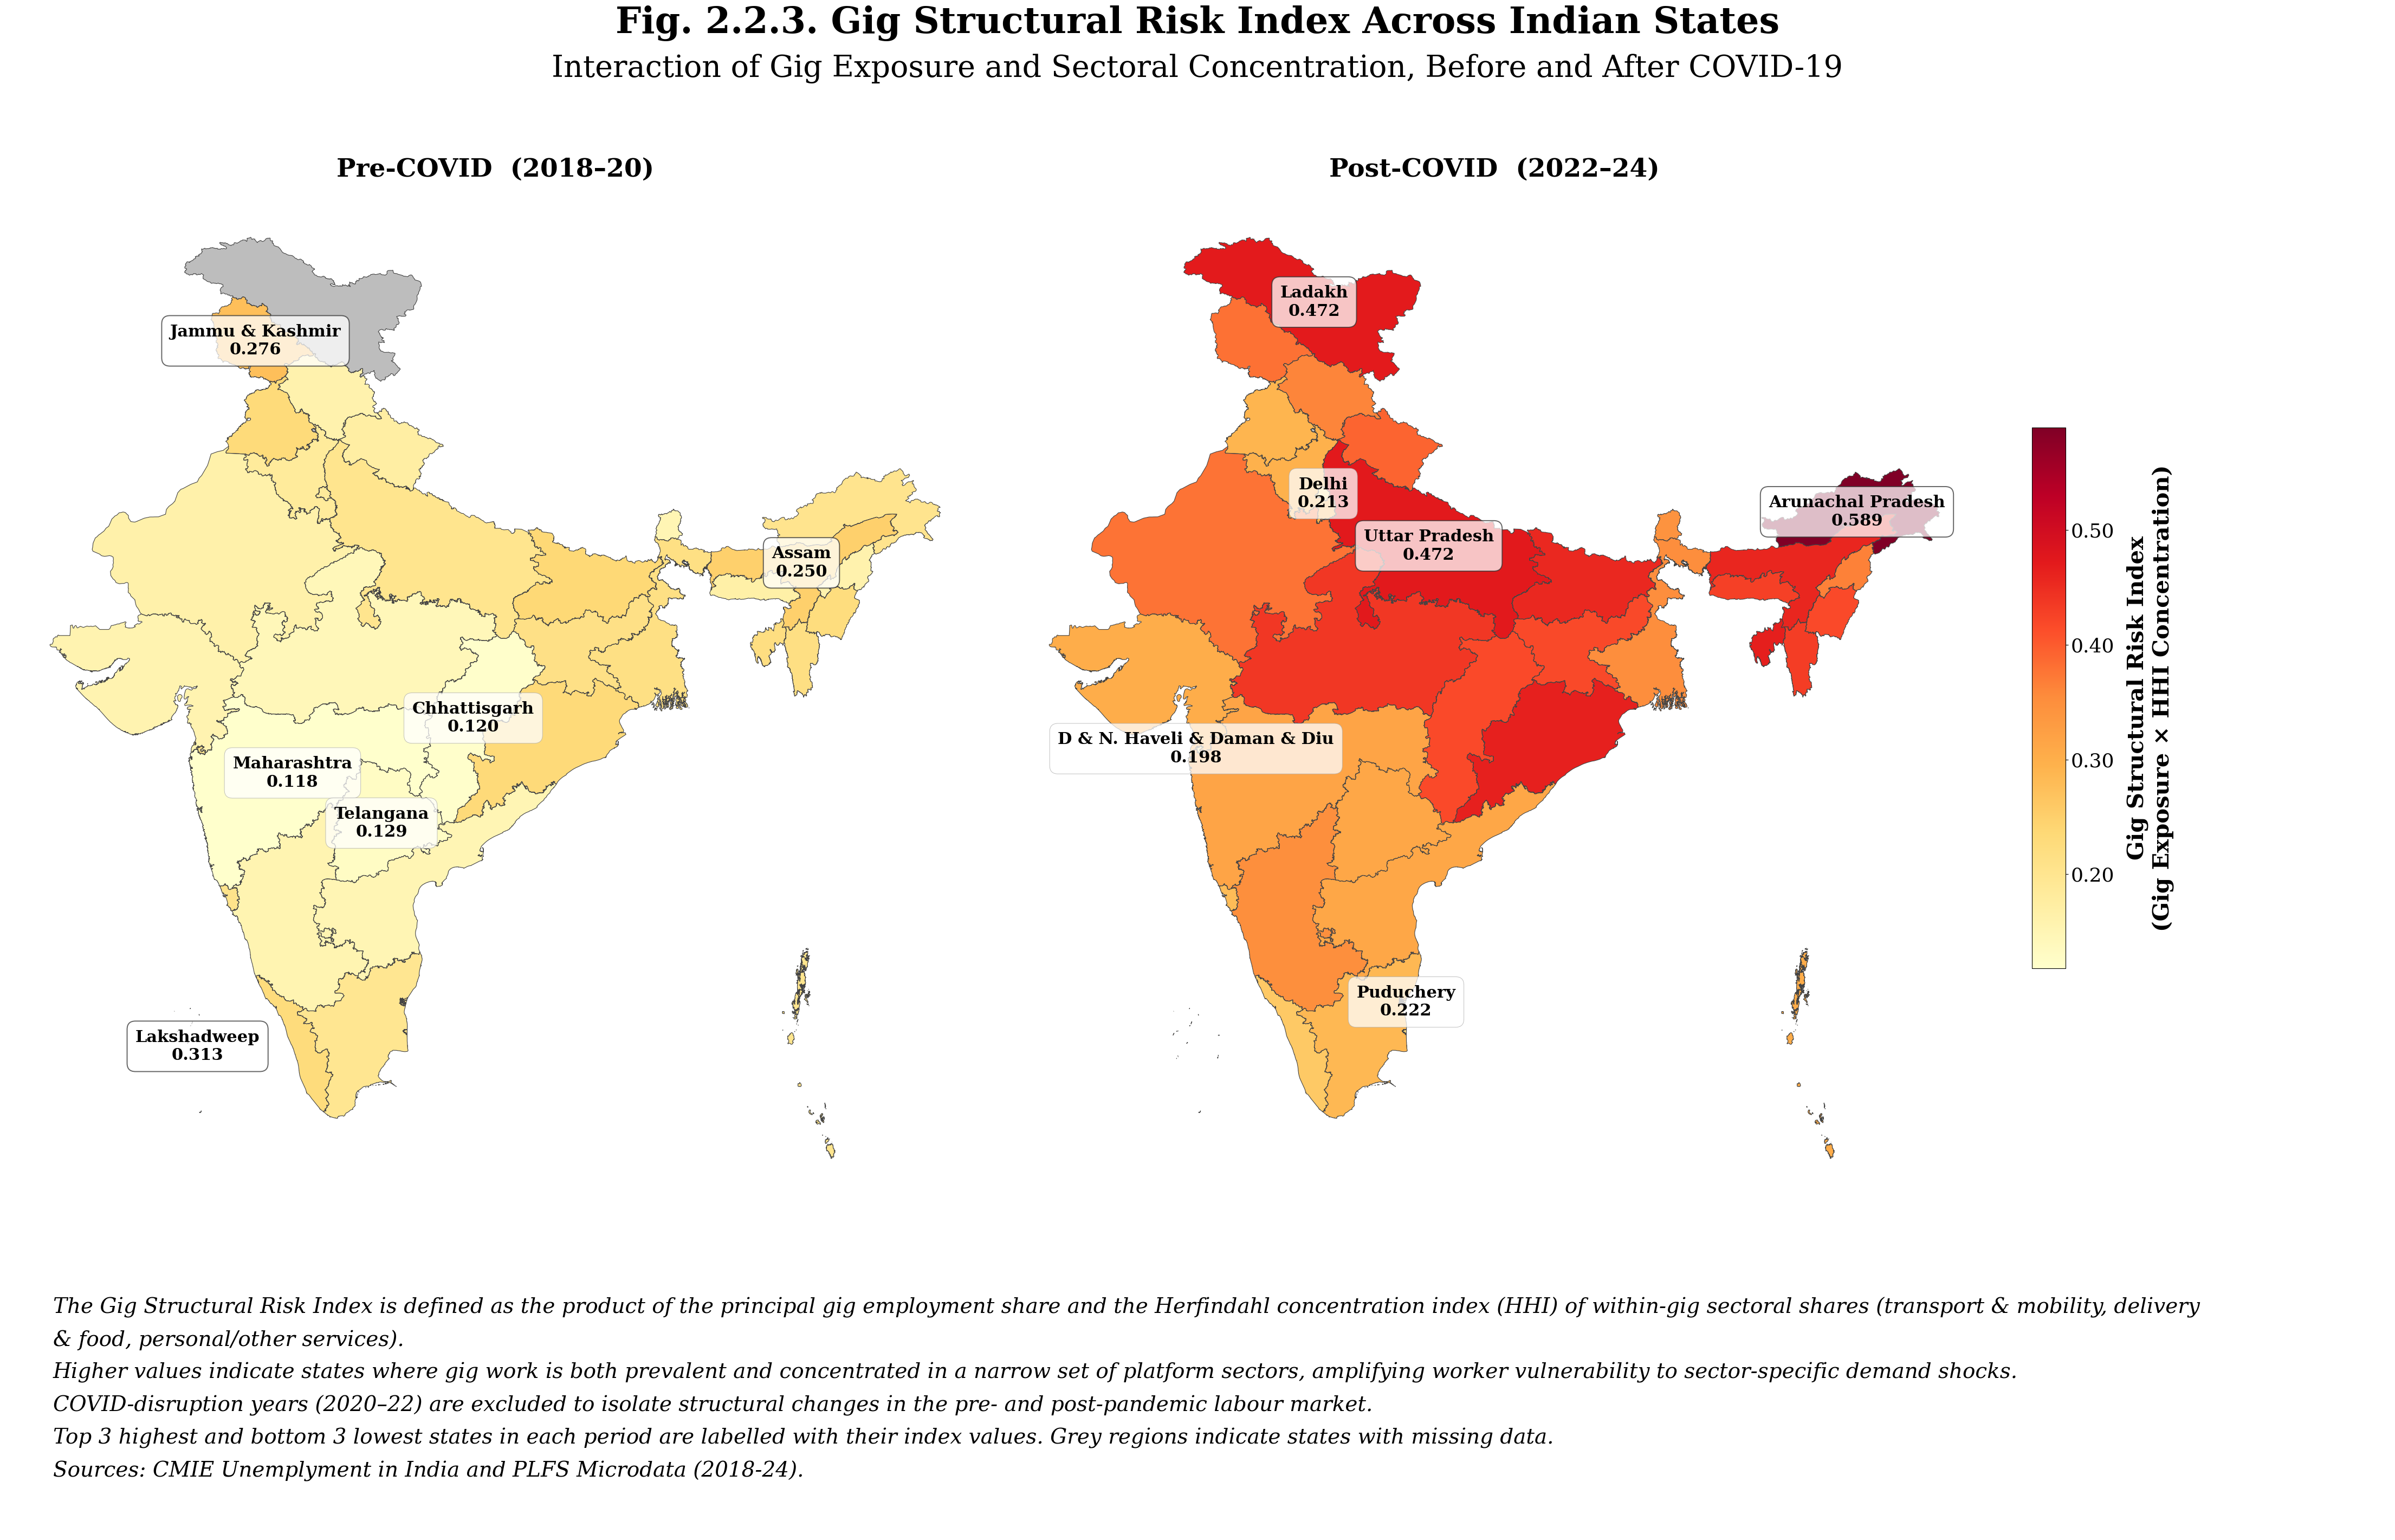

In [1]:
# ============================================================
# FIGURE: GIG STRUCTURAL RISK INDEX
# Pre-COVID vs Post-COVID
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np

plt.rcParams.update({"font.family": "serif"})

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("final_dataset.csv")

# ------------------------------------------------------------
# 2. BUILD DERIVED VARIABLES
# ------------------------------------------------------------
for col in [
    "gig_transport_share_within_gig",
    "gig_delivery_food_share_within_gig",
    "gig_personal_other_share_within_gig",
    "gig_employment_share_principal",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

share_sum = (
    df["gig_transport_share_within_gig"].fillna(0) +
    df["gig_delivery_food_share_within_gig"].fillna(0) +
    df["gig_personal_other_share_within_gig"].fillna(0)
)
for raw, norm in [
    ("gig_transport_share_within_gig",     "gig_transport_share_norm"),
    ("gig_delivery_food_share_within_gig", "gig_delivery_food_share_norm"),
    ("gig_personal_other_share_within_gig","gig_personal_other_share_norm"),
]:
    df[norm] = np.where(share_sum > 0, df[raw].fillna(0) / share_sum, np.nan)

df["gig_hhi_concentration"] = (
    df["gig_transport_share_norm"]**2 +
    df["gig_delivery_food_share_norm"]**2 +
    df["gig_personal_other_share_norm"]**2
)
df["gig_structural_risk_index"] = (
    df["gig_employment_share_principal"] *
    df["gig_hhi_concentration"]
)

# ------------------------------------------------------------
# 3. ORANGE COLORMAP
# ------------------------------------------------------------
colors_orange = [
    "#FFFFCC",
    "#FFEDA0",
    "#FED976",
    "#FEB24C",
    "#FD8D3C",
    "#FC4E2A",
    "#E31A1C",
    "#BD0026",
    "#800026",
]
cmap_orange = LinearSegmentedColormap.from_list("OrangeRisk", colors_orange, N=512)

# ------------------------------------------------------------
# 4. YEAR LABELS AND WEIGHT COLUMN
# ------------------------------------------------------------
pre_years  = ["2018_19", "2019_20"]
post_years = ["2022_23", "2023_24"]

weight_col = "employed_weighted"
if weight_col not in df.columns:
    weight_col = "gig_employed_weighted"

# ------------------------------------------------------------
# 5. HELPER: WEIGHTED AVERAGE
# ------------------------------------------------------------
def wavg(g, value_col, w_col):
    x = pd.to_numeric(g[value_col], errors="coerce")
    w = pd.to_numeric(g[w_col],     errors="coerce")
    mask = x.notna() & w.notna() & (w > 0)
    return np.average(x[mask], weights=w[mask]) if mask.any() else np.nan

# ------------------------------------------------------------
# 6. STATE-LEVEL PRE / POST SUMMARIES
# ------------------------------------------------------------
def build_summary(sub_df, risk_col, w_col, suffix):
    rows = []
    for state, g in sub_df.groupby("state", dropna=False):
        rows.append({
            "state":                     state,
            f"structural_risk_{suffix}": wavg(g, risk_col, w_col),
        })
    return pd.DataFrame(rows)

pre_df  = df[df["year_label"].isin(pre_years)].copy()
post_df = df[df["year_label"].isin(post_years)].copy()

pre_summary  = build_summary(pre_df,  "gig_structural_risk_index", weight_col, "pre")
post_summary = build_summary(post_df, "gig_structural_risk_index", weight_col, "post")

# ------------------------------------------------------------
# 7. LOAD AND CLEAN INDIA SHAPEFILE
# ------------------------------------------------------------
india_states_url = (
    "https://github.com/wmgeolab/geoBoundaries/raw/9469f09/"
    "releaseData/gbOpen/IND/ADM1/geoBoundaries-IND-ADM1.geojson"
)
india_states = gpd.read_file(india_states_url)

state_name_fixes = {
    "Tamil Nādu":                               "Tamilnadu",
    "Jammu and Kashmīr":                        "Jammu & Kashmir",
    "Ladākh":                                   "Ladakh",
    "Puducherry":                               "Puduchery",
    "Andaman and Nicobar Islands":              "Andaman & N. Island",
    "Dādra and Nagar Haveli and Damān and Diu": "D & N. Haveli & Daman & Diu",
    "Mahārāshtra":                              "Maharashtra",
    "Chhattīsgarh":                             "Chhattisgarh",
    "Gujarāt":                                  "Gujarat",
    "Bihār":                                    "Bihar",
    "Rājasthān":                                "Rajasthan",
    "Telangāna":                                "Telangana",
    "Karnātaka":                                "Karnataka",
    "Jhārkhand":                                "Jharkhand",
    "Haryāna":                                  "Haryana",
    "Uttarākhand":                              "Uttarakhand",
    "Himāchal Pradesh":                         "Himachal Pradesh",
    "Arunāchal Pradesh":                        "Arunachal Pradesh",
    "Meghālaya":                                "Meghalaya",
    "Nāgāland":                                 "Nagaland",
}
india_states["shapeName"] = india_states["shapeName"].replace(state_name_fixes)

map_pre  = india_states.merge(pre_summary,  left_on="shapeName", right_on="state", how="left")
map_post = india_states.merge(post_summary, left_on="shapeName", right_on="state", how="left")

# ------------------------------------------------------------
# 8. SHARED COLOR SCALE
# ------------------------------------------------------------
vmin = np.nanmin([map_pre["structural_risk_pre"].min(),  map_post["structural_risk_post"].min()])
vmax = np.nanmax([map_pre["structural_risk_pre"].max(),  map_post["structural_risk_post"].max()])

# ------------------------------------------------------------
# 9. OUTLIER LABEL HELPER
# ------------------------------------------------------------
def get_outlier_labels(gdf, col):
    top3    = gdf.nlargest(3,  col)
    bottom3 = gdf.nsmallest(3, col)
    outliers = pd.concat([top3, bottom3]).drop_duplicates(subset=["shapeName"])
    proj      = outliers.to_crs("EPSG:32644")
    centroids = proj.geometry.centroid.to_crs("EPSG:4326")
    return outliers, centroids, top3

outliers_pre,  centroids_pre,  top3_pre  = get_outlier_labels(map_pre,  "structural_risk_pre")
outliers_post, centroids_post, top3_post = get_outlier_labels(map_post, "structural_risk_post")

# ------------------------------------------------------------
# 10. FIGURE LAYOUT
# ------------------------------------------------------------
fig = plt.figure(figsize=(50, 34))          # wider + taller canvas

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[0.06, 1, 0.18],
    width_ratios=[1, 1],
    hspace=0.04,
    wspace=0.02,
    figure=fig,
)

# Push maps rightward, leave room for colorbar on far right
fig.subplots_adjust(left=0, right=0.88, top=0.95, bottom=0.12)

title_ax    = fig.add_subplot(gs[0, :])
ax_pre      = fig.add_subplot(gs[1, 0])
ax_post     = fig.add_subplot(gs[1, 1])
footnote_ax = fig.add_subplot(gs[2, :])

for a in (title_ax, footnote_ax):
    a.set_axis_off()

# ------------------------------------------------------------
# 11. TITLES
# ------------------------------------------------------------
title_ax.text(
    0.5, 0.75,
    "Fig. 2.2.3. Gig Structural Risk Index Across Indian States",
    transform=title_ax.transAxes, ha="center", va="center",
    fontsize=48, fontweight="bold",
)
title_ax.text(
    0.5, 0.12,
    "Interaction of Gig Exposure and Sectoral Concentration, Before and After COVID-19",
    transform=title_ax.transAxes, ha="center", va="center",
    fontsize=40
)

# ------------------------------------------------------------
# 12. DRAW MAPS
# ------------------------------------------------------------
panels = [
    (ax_pre,  map_pre,  "structural_risk_pre",  outliers_pre,  centroids_pre,  top3_pre,
     "Pre-COVID  (2018–20)"),
    (ax_post, map_post, "structural_risk_post", outliers_post, centroids_post, top3_post,
     "Post-COVID  (2022–24)"),
]

for ax, gdf, col, outliers, centroids, top3, subtitle in panels:

    gdf.plot(
        ax=ax, column=col,
        cmap=cmap_orange,
        vmin=vmin, vmax=vmax,
        legend=False,
        missing_kwds={"color": "#BDBDBD", "label": "No Data"},
        zorder=1,
    )
    gdf.boundary.plot(ax=ax, linewidth=0.8, color="#444444", zorder=2)

    for centroid, (_, row) in zip(centroids, outliers.iterrows()):
        is_top = row["shapeName"] in top3["shapeName"].values
        ax.annotate(
            f"{row['shapeName']}\n{row[col]:.3f}",
            xy=(centroid.x, centroid.y),
            fontsize=22, ha="center", va="center",
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor="white", alpha=0.75,
                edgecolor="#333333" if is_top else "#aaaaaa",
                linewidth=1.4 if is_top else 0.7,
            ),
        )

    ax.set_title(subtitle, fontsize=34, fontweight="bold", pad=20)
    ax.set_axis_off()
    ax.set_aspect("equal")

# ------------------------------------------------------------
# 13. SHARED VERTICAL COLORBAR
# ------------------------------------------------------------
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm   = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_orange)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=[ax_pre, ax_post],
    orientation="vertical",
    shrink=0.45, aspect=16, pad=0.02,
    format="%.2f",
)
cbar.set_label(
    "Gig Structural Risk Index\n(Gig Exposure × HHI Concentration)",
    size=30, weight="bold", labelpad=16,
)
cbar.ax.tick_params(labelsize=26)

# ------------------------------------------------------------
# 14. FOOTNOTE
# ------------------------------------------------------------
footnote_text = (
    "The Gig Structural Risk Index is defined as the product of the principal gig employment share and the Herfindahl "
    "concentration index (HHI) of within-gig sectoral shares (transport & mobility, delivery\n" 
    "& food, personal/other services).\n"
    "Higher values indicate states where gig work is both prevalent and concentrated in a narrow set of platform sectors, "
    "amplifying worker vulnerability to sector-specific demand shocks.\n"
    "COVID-disruption years (2020–22) are excluded to "
    "isolate structural changes in the pre- and post-pandemic labour market.\n"
    "Top 3 highest and bottom 3 lowest states in each period are labelled with their index values. "
    "Grey regions indicate states with missing data.\n"
    "Sources: CMIE Unemplyment in India and PLFS Microdata (2018-24)."
)

footnote_ax.text(
    0.02, 1.10, footnote_text,
    transform=footnote_ax.transAxes, ha="left", va="top",
    fontsize=28, linespacing=1.75,
    style="italic"
)

plt.show()

Fig 2.2.3 presents a state-level Gig Structural Risk Index for the pre- and post-COVID periods, calculated as gig employment exposure multiplied by sectoral concentration (Herfindahl index) across transport, delivery, and personal services. Higher values indicate labour markets where gig work is both prevalent and concentrated, implying greater exposure to sector-specific shocks.

Structural gig risk rises and becomes more spatially dispersed post-COVID, particularly in Arunachal Pradesh, Uttar Pradesh, and Ladakh. This suggests gig expansion in some states became increasingly sectorally concentrated. Consequently, gig exposure does not uniformly translate into higher vulnerable employment, as outcomes depend on the sectoral composition as well as the scale of gig work.

##2.3 Regressions

The relationship between X and Y is modeled as non-linear, as gig work may initially supplement employment but increasingly substitute formal jobs as exposure rises. Accordingly, regressions include a quadratic term for gig exposure to capture increasing marginal effects.

Pre-estimation diagnostics indicate heteroskedasticity and scale instability. The gig volatility wedge is log-transformed to stabilize variance, and extreme values in the male–female gig worker ratio are winsorized at the 99th percentile. Standard errors are clustered at the state level to account for heteroskedasticity and within-state correlation.

In [42]:
# ============================================================
# Baseline, nonlinearity, and mechanism-building
# ============================================================

!pip install stargazer -q

import re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("final_dataset.csv")

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# ------------------------------------------------------------
# 2. VARIABLE CONSTRUCTION
# ------------------------------------------------------------

df["Y"]      = to_num(df["vulnerable_employment_share"])
df["X1"]     = to_num(df["gig_employment_share_principal"])
df["X1_sq"]  = df["X1"]**2
df["Z"]      = to_num(df["gig_precarity_index"])
df["X2_raw"] = to_num(df["gig_volatility_wedge_occ"])
df["X2"]     = np.log(df["X2_raw"] + 0.001)
df["X3"]     = to_num(df["gig_num_workers_enterprise_share"])
df["X4"]     = to_num(df["gig_workplace_location_code_share"])
df["X5"]     = to_num(df["gig_age_15_34_share_within_gig"])
df["X6"]     = to_num(df["gig_edu_secondary_tertiary_share_within_gig"])

df["male_share"]   = to_num(df["gig_male_share_within_gig"])
df["female_share"] = to_num(df["gig_female_share_within_gig"])
df["X7"] = df["male_share"] / df["female_share"].replace(0, np.nan)
df["X7"] = df["X7"].clip(upper=df["X7"].quantile(0.99))

# ------------------------------------------------------------
# 3. HELPER FUNCTION
# ------------------------------------------------------------

def fit_cluster_ols(formula, data):
    needed_cols = list(
        set(re.findall(r"\b[A-Za-z_][A-Za-z0-9_]*\b", formula))
        & set(data.columns)
    )
    d = data.copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=needed_cols + ["state"])
    return smf.ols(formula=formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["state"]}
    )

# ------------------------------------------------------------
# 4. REGRESSION SPECIFICATIONS
# ------------------------------------------------------------

f0 = "Y ~ X1"
f1 = "Y ~ X1 + X1_sq"
f2 = "Y ~ X1 + X1_sq + X2 + X3 + X4"
f3 = "Y ~ X1 + X1_sq + X5 + X6 + X7"
f4 = "Y ~ X1 + X1_sq + X2 + X3 + X4 + X5 + X6 + X7 + X1:Z"

m0 = fit_cluster_ols(f0, df)
m1 = fit_cluster_ols(f1, df)
m2 = fit_cluster_ols(f2, df)
m3 = fit_cluster_ols(f3, df)
m4 = fit_cluster_ols(f4, df)

# ------------------------------------------------------------
# 5. FORMATTING HELPERS
# ------------------------------------------------------------

rename_map = {
    "Intercept": "Intercept",
    "X1":    "Gig exposure share (X1)",
    "X1_sq": "Gig exposure share squared (X1²)",
    "X1:Z":  "Gig exposure × gig precarity (X1 × Z)",
    "X2":    "Log gig volatility wedge (X2)",
    "X3":    "Small/informal enterprise share (X3)",
    "X4":    "No fixed workplace share (X4)",
    "X5":    "Gig workers aged 15–34 (X5)",
    "X6":    "Secondary/tertiary education share (X6)",
    "X7":    "Male-to-female ratio (X7)",
}

def clean_stargazer_html(html):
    # Remove automatic model-number row
    html = re.sub(
        r"<tr>\s*<td[^>]*></td>\s*(<td[^>]*>\(\d+\)</td>\s*){2,10}</tr>",
        "", html, flags=re.DOTALL
    )

    # Aggressively compact table style
    html = html.replace(
        '<table style="text-align:center">',
        '<table style="text-align:center; width:100%; table-layout:fixed; border-collapse:collapse; font-size:9.5px; line-height:1.05; font-family:Times New Roman;">'
    )

    # Colgroup — narrower variable col, wider model cols
    html = html.replace(
        '<table style="text-align:center; width:100%; table-layout:fixed; border-collapse:collapse; font-size:9.5px; line-height:1.05; font-family:Times New Roman;">',
        '<table style="text-align:center; width:100%; table-layout:fixed; border-collapse:collapse; font-size:9.5px; line-height:1.05; font-family:Times New Roman;"><colgroup><col style="width:30%"><col style="width:14%"><col style="width:14%"><col style="width:14%"><col style="width:14%"><col style="width:14%"></colgroup>'
    )

    # Minimal padding
    html = html.replace("<td>", '<td style="padding:1px 3px; vertical-align:middle;">')
    html = html.replace("<th>", '<th style="padding:1px 3px; vertical-align:middle; white-space:normal;">')

    return html

# ------------------------------------------------------------
# 6. CREATE TABLE
# ------------------------------------------------------------

star = Stargazer([m0, m1, m2, m3, m4])

star.title(
    "<center><span style='font-size:14px; font-weight:bold; font-family:Times New Roman;'>"
    "Table 2.3.1: Baseline, Nonlinearity, and Mechanism Building"
    "</span></center>"
)

star.dependent_variable_name("Vulnerable employment share")

star.custom_columns(
    [
        "Benchmark",
        "Quadratic",
        "+ Structural",
        "+ Composition",
        "+ Mechanism"
    ],
    [1, 1, 1, 1, 1]
)

star.rename_covariates(rename_map)

star.covariate_order([
    "X1",
    "X1_sq",
    "X1:Z",
    "X2", "X3", "X4",
    "X5", "X6", "X7",
    "Intercept"
])

star.show_degrees_of_freedom = False
star.show_residual_std_err   = True
star.show_f_statistic        = True
star.significant_digits(3)

html = clean_stargazer_html(star.render_html())

# ------------------------------------------------------------
# 7. FOOTNOTE
# ------------------------------------------------------------

notes = """
<div style="font-family:Times New Roman; font-size:9.5px; margin-top:4px; text-align:left;">
<b>Notes:</b> Standard errors are clustered at the state level.
Columns progress from a bare-bones benchmark through quadratic exposure,
structural controls, composition controls, and a full specification
with the gig exposure × precarity interaction mechanism.
</div>
"""

# Wrap in print-friendly div that forces single page
display(HTML(f"""
<div style="font-size:9.5px; line-height:1.05; page-break-inside:avoid;">
{html}
{notes}
</div>
"""))

Table 2.3.1 evaluates whether the relationship between X and Y reflects scale effects, workforce composition, or structural features of gig labour markets.

Column (1) presents a benchmark specification including only gig exposure. Here, labour markets with greater gig participation tend to exhibit higher vulnerable employment. However, this reduced-form specification does not account for labour-market structure or worker composition.

Column (2) introduces a quadratic term to test for non-linearity. The positive and significant quadratic coefficient indicates a convex relationship, suggesting that vulnerability rises more rapidly as gig work becomes more prevalent and increasingly substitutes formal employment.

Column (3) adds structural characteristics of gig labour market which contributes to the weakening of the exposure coefficient and suggests that part of the gig–vulnerability relationship reflects the institutional structure of gig work.

Column (4) instead includes workforce composition controls to account for potential worker sorting into gig employment. Higher youth shares are associated with greater vulnerability, consistent with weaker labour-market attachment, while higher education levels are linked to lower vulnerability. However, the persistence of the nonlinear exposure pattern indicates that demographic composition alone does not explain the relationship.

Column (5) combines the controls and introduces an interaction between gig exposure and gig precarity. The significant interaction indicates that the impact of gig expansion depends on the institutional quality of gig work. Vulnerability rises mainly where gig growth occurs under weaker employment protections, not from exposure alone.

In [39]:
# ============================================================
# TABLE 5.2
# Sectoral refinement and fixed-effects robustness
# ============================================================

!pip install stargazer -q

import re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("final_dataset.csv")

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# ------------------------------------------------------------
# 2. VARIABLE CONSTRUCTION
# ------------------------------------------------------------

df["Y"]      = to_num(df["vulnerable_employment_share"])
df["X1"]     = to_num(df["gig_employment_share_principal"])
df["X1_sq"]  = df["X1"]**2
df["Z"]      = to_num(df["gig_precarity_index"])
df["X2_raw"] = to_num(df["gig_volatility_wedge_occ"])
df["X2"]     = np.log(df["X2_raw"] + 0.001)
df["X3"]     = to_num(df["gig_num_workers_enterprise_share"])
df["X4"]     = to_num(df["gig_workplace_location_code_share"])
df["X5"]     = to_num(df["gig_age_15_34_share_within_gig"])
df["X6"]     = to_num(df["gig_edu_secondary_tertiary_share_within_gig"])

df["male_share"]   = to_num(df["gig_male_share_within_gig"])
df["female_share"] = to_num(df["gig_female_share_within_gig"])
df["X7"] = df["male_share"] / df["female_share"].replace(0, np.nan)
df["X7"] = df["X7"].clip(upper=df["X7"].quantile(0.99))

df["X8"]  = to_num(df["gig_transport_share_within_gig"])
df["X9"]  = to_num(df["gig_delivery_food_share_within_gig"])
df["X10"] = to_num(df["gig_personal_other_share_within_gig"])

df["urban"]   = (df["region"].astype(str).str.strip().str.title() == "Urban").astype(int)
df["time_fe"] = df["year_label"].astype(str) + "_" + df["quarter"].astype(str)

# ------------------------------------------------------------
# 3. HELPER FUNCTION
# ------------------------------------------------------------
def fit_cluster_ols(formula, data):
    needed_cols = list(
        set(re.findall(r"\b[A-Za-z_][A-Za-z0-9_]*\b", formula))
        & set(data.columns)
    )
    d = data.copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=needed_cols + ["state"])
    return smf.ols(formula=formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["state"]}
    )

# ------------------------------------------------------------
# 4. REGRESSION SPECIFICATIONS
# ------------------------------------------------------------

f5 = "Y ~ X1 + X1_sq + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10 + X1:Z"
f6 = "Y ~ X1 + X1_sq + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10 + urban + X1:Z"
f7 = "Y ~ X1 + X1_sq + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10 + urban + C(state) + X1:Z"
f8 = "Y ~ X1 + X1_sq + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10 + urban + C(time_fe) + X1:Z"
f9 = "Y ~ X1 + X1_sq + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 + X10 + urban + C(state) + C(time_fe) + X1:Z"

m5 = fit_cluster_ols(f5, df)
m6 = fit_cluster_ols(f6, df)
m7 = fit_cluster_ols(f7, df)
m8 = fit_cluster_ols(f8, df)
m9 = fit_cluster_ols(f9, df)

# ------------------------------------------------------------
# 5. FORMATTING HELPERS
# ------------------------------------------------------------
rename_map = {
    "Intercept": "Intercept",
    "X1":    "Gig exposure share (X1)",
    "X1_sq": "Gig exposure share squared (X1²)",
    "X1:Z":  "Gig exposure × gig precarity (X1 × Z)",
    "X2":    "Log gig volatility wedge (X2)",
    "X3":    "Small/informal enterprise share (X3)",
    "X4":    "No fixed workplace share (X4)",
    "X5":    "Gig workers aged 15–34 (X5)",
    "X6":    "Secondary/tertiary education share (X6)",
    "X7":    "Male-to-female ratio (X7)",
    "X8":    "Transport gig share (X8)",
    "X9":    "Delivery & food gig share (X9)",
    "X10":   "Personal & other services share (X10)",
    "urban": "Urban labour market (=1)"
}

def clean_stargazer_html(html):
    # Remove FE coefficient rows
    html = re.sub(r"<tr>.*?C\(state\)\[T\..*?</tr>",   "", html, flags=re.DOTALL)
    html = re.sub(r"<tr>.*?C\(time_fe\)\[T\..*?</tr>", "", html, flags=re.DOTALL)
    html = re.sub(r"<tr>.*?C\(region\)\[T\..*?</tr>",  "", html, flags=re.DOTALL)

    # Remove automatic model-number row
    html = re.sub(
        r"<tr>\s*<td[^>]*></td>\s*(<td[^>]*>\(\d+\)</td>\s*){2,10}</tr>",
        "", html, flags=re.DOTALL
    )

    # Aggressively compact table style
    html = html.replace(
        '<table style="text-align:center">',
        '<table style="text-align:center; width:100%; table-layout:fixed; border-collapse:collapse; font-size:9.5px; line-height:1.05; font-family:Times New Roman;">'
    )

    # Colgroup — narrower variable col
    html = html.replace(
        '<table style="text-align:center; width:100%; table-layout:fixed; border-collapse:collapse; font-size:9.5px; line-height:1.05; font-family:Times New Roman;">',
        '<table style="text-align:center; width:100%; table-layout:fixed; border-collapse:collapse; font-size:9.5px; line-height:1.05; font-family:Times New Roman;"><colgroup><col style="width:30%"><col style="width:14%"><col style="width:14%"><col style="width:14%"><col style="width:14%"><col style="width:14%"></colgroup>'
    )

    # Minimal padding
    html = html.replace("<td>", '<td style="padding:1px 3px; vertical-align:middle;">')
    html = html.replace("<th>", '<th style="padding:1px 3px; vertical-align:middle; white-space:normal;">')

    return html

def add_model_info_lines(star, models):
    formulas = [m.model.formula for m in models]
    state_fe        = ["Yes" if "C(state)"   in f else "No" for f in formulas]
    quarter_year_fe = ["Yes" if "C(time_fe)" in f else "No" for f in formulas]
    star.add_line("State fixed effects",        state_fe)
    star.add_line("Quarter-year fixed effects", quarter_year_fe)

# ------------------------------------------------------------
# 6. RENDER TABLE
# ------------------------------------------------------------
star2 = Stargazer([m5, m6, m7, m8, m9])

star2.title(
    "<center><span style='font-size:14px; font-weight:bold; font-family:Times New Roman;'>"
    "Table 2.3.2: Sectoral Refinement and Fixed-Effects Robustness"
    "</span></center>"
)

star2.dependent_variable_name("Vulnerable employment share")

star2.custom_columns(
    [
        "+ Industry controls",
        "+ Urban",
        "+ State FE",
        "+ Quarter-year FE",
        "Full model"
    ],
    [1, 1, 1, 1, 1]
)

star2.rename_covariates(rename_map)

star2.covariate_order([
    "X1", "X1_sq", "X1:Z",
    "X2", "X3", "X4",
    "X5", "X6", "X7",
    "X8", "X9", "X10",
    "urban",
    "Intercept"
])

star2.show_degrees_of_freedom = False
star2.show_f_statistic        = True
star2.show_residual_std_err   = True
star2.significant_digits(3)

add_model_info_lines(star2, [m5, m6, m7, m8, m9])

html2 = clean_stargazer_html(star2.render_html())

notes2 = """
<div style="font-family:Times New Roman; font-size:9.5px; margin-top:4px; text-align:left;">
<b>Notes:</b> All specifications include the interaction between gig exposure and gig precarity
to examine whether weaker employment protection amplifies the vulnerability-exposure relationship.
Standard errors are clustered at the state level.
</div>
"""

# Wrap in print-friendly div that forces single page
display(HTML(f"""
<div style="font-size:9.5px; line-height:1.05; page-break-inside:avoid;">
{html2}
{notes2}
</div>
"""))

Table 2.3.2 tests whether the relationship between X, Y, Z remains robust once sectoral composition and labour-market heterogeneity are considered. Across all specifications, the interaction between gig exposure and gig precarity remains large and consistently significant, indicating that the labour-market consequences of gig expansion depend on the institutional conditions under which gig work occurs than exposure alone.

Column (1) introduces industry composition controls to account for differences in the sectors through which gig work expands. The negative coefficients suggest that variation in gig industries alone does not mechanically increase vulnerability. Instead, vulnerability appears linked to broader labour-market structures rather than specific gig industries.

Column (2) introduces an indicator to capture structural differences between urban and rural employment environments. The negative coefficient indicates lower vulnerability in urban labour markets, consistent with employment diversification and access to alternative opportunities.

Columns (3) and (4) incorporate state and quarter-year fixed effects to control for unobserved labour-market institutions and macroeconomic shocks. The persistence of the interaction effect across these specifications suggests that the gig exposure–precarity relationship is not driven by time-invariant state characteristics or aggregate shocks.

Column (5) presents the full specification with sectoral controls and both fixed effects. The stability of the interaction term and improved model fit indicate that differences in labour-market institutions and protections explain much of the variation in vulnerable employment. Overall, the results reinforce that gig expansion increases vulnerability primarily where gig work operates under weaker employment protections.

Across both tables, most controls have negative coefficients, contrary to expectations, likely due to downward bias from reverse causality, as gig exposure cannot be instrumented with the available data.


The preferred specification includes structural and compositional controls, the gig exposure–precarity interaction, and state and quarter–year fixed effects. It controls forlabour-market structure, workforce composition, sectoral differences, and unobserved state and time heterogeneity while directly testing whether gig expansion increases vulnerability where employment protections are weak.

$$
Y_{s,t} =
\beta_0
+ \beta_1 X_{1,s,t}
+ \beta_2 X_{1,s,t}^2
+ \beta_3 (X_{1,s,t} \times Z_{s,t})
+ \sum_{k=2}^{10} \beta_k X_{k,s,t}
+ \gamma_s
+ \delta_t
+ \varepsilon_{s,t}
$$

$$
\begin{aligned}
Y_{s,t} & : \text{vulnerable employment} \\
X_{1,s,t} & : \text{gig exposure} \\
Z_{s,t} & : \text{gig precarity index} \\
X_{2,s,t}\text{–}X_{10,s,t} & : \text{structural, demographic, and sectoral controls} \\
\gamma_s & : \text{state fixed effects} \\
\delta_t & : \text{quarter–year fixed effects}
\end{aligned}
$$


Model evaluation prioritizes the specification that most directly tests the proposed mechanism while statistical diagnostics are used as supporting evidence. The preferred specification includes the gig exposure–precarity interaction and fixed effects, allowing the analysis to test whether higher gig exposure is associated with greater vulnerability under weaker employment protections, linking empirical results to the research question and theoretical framework.

In [7]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# Main page
url = "https://www.trai.gov.in/release-publication/reports/telecom-subscriptions-reports"
response = requests.get(url)
print("Main page status code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

# Collect candidate report/detail links from the page
candidate_links = []
for a in soup.find_all("a", href=True):
    text = a.get_text(" ", strip=True)
    href = a["href"].strip()
    full_link = urljoin(url, href)
    
    if "telecom subscription" in text.lower() or "subscription data" in text.lower():
        candidate_links.append((text, full_link))

print("\nMain report link:")
for text, link in candidate_links[:10]:
    print(text, "->", link)

# Visit a few candidate links and look for actual PDF links
pdf_links = []

for text, link in candidate_links[:5]:
    try:
        r = requests.get(link, timeout=20)
        print(f"\nChecking: {link}")
        print("Status code:", r.status_code)
        
        sub_soup = BeautifulSoup(r.text, "html.parser")
        for a in sub_soup.find_all("a", href=True):
            href = a["href"].strip()
            full_pdf = urljoin(link, href)
            if ".pdf" in href.lower():
                pdf_links.append((a.get_text(" ", strip=True), full_pdf))
    except Exception as e:
        print("Error:", e)

print("\nRelevant PDF links found:")
for text, link in pdf_links[:10]:
    print(text, "->", link)

Main page status code: 200

Main report link:
Telecom Subscription Reports -> https://www.trai.gov.in/release-publication/reports/telecom-subscriptions-reports

Checking: https://www.trai.gov.in/release-publication/reports/telecom-subscriptions-reports
Status code: 200

Relevant PDF links found:
Registration of COs with TRAI -> https://www.trai.gov.in/sites/default/files/2026-01/Scheme_Registration_CAG.pdf
Download (1.22 MB) -> https://www.trai.gov.in/sites/default/files/2026-03/PR_No.39of2026_0.pdf
Download (5.71 MB) -> https://www.trai.gov.in/sites/default/files/2026-02/PR_No.19of2026_0.pdf
Download (2.42 MB) -> https://www.trai.gov.in/sites/default/files/2025-12/English%20Press%20Release%20of%20Telecom%20Subscription%20Data-November-25_English-31.12.2025_1815-sd_0.pdf
Download (12.52 MB) -> https://www.trai.gov.in/sites/default/files/2025-11/PR_No.141of2025_0.pdf
Download (2.13 MB) -> https://www.trai.gov.in/sites/default/files/2025-10/PR_No.120of2025_0.pdf
Download (2.38 MB) -> htt

In [ ]:
# Regression Tree
from sklearn import tree
sqft_tree = tree.DecisionTreeRegressor(max_depth=3).fit(X,y)

In [ ]:
# use the fitted tree to predict
y_pred_tree = sqft_tree.predict(X)

# find the error of prediction (MSE)
from sklearn import metrics
print('Mean Squared Error:', metrics.mean_squared_error(y, y_pred_tree))

In [ ]:
sqrf_fig = plt.figure(figsize=(25,20))
sqrf_fig = tree.plot_tree(sqft_tree, feature_names=X.columns, filled=True)

##2.5 Conclusion

Using CMIE and PLFS data, this study examines whether the expansion of platform-adjacent employment in India is associated with higher labour-market vulnerability through gaps in employment protection. Descriptive evidence shows rising gig exposure across states post-COVID while vulnerable employment remains high. Spatial patterns reveal substantial heterogeneity, with labour markets exhibiting different vulnerability outcomes despite similar levels of gig exposure.

Regression results indicate that although gig exposure is positively associated with vulnerable employment, this relationship weakens once structural and compositional characteristics are included. Instead, the interaction between gig exposure and gig precarity remains consistently significant, implying that the labour-market effects of gig expansion depend on the institutional conditions of gig work, including employment protections and contractual arrangements. Sectoral and geographic differences further shape how gig expansion translates into vulnerability.

The findings should be interpreted as associational rather than causal. A difference-in-differences strategy was not feasible due to violations of the parallel trends assumption, and an instrumental-variable approach could not be implemented given the absence of reliable measures of digital infrastructure, such as broadband or mobile connectivity. Future research could incorporate such measures as potential instruments for gig expansion to address reverse causality and enable causal identification. Access to richer sectoral or platform-level data would also improve measurement of the institutional organization of gig work.

The results should be interpreted as associational rather than causal. A DiD strategy was not feasible due to violations of the parallel trends assumption, and an IV approach could not be implemented as measures of digital infrastructure were unavailable. Future research could incorporate such measures as potential instruments to address reverse causality. Additionally, richer sectoral or platform-level data should capture institutional organization of gig work better.

Overall, the findings suggest that the labour-market consequences of gig expansion depend less on its scale than on the institutional environment governing gig work, highlighting the importance of employment protections in rapidly digitalizing labour markets.

References:
1.  Aggarwal, S. C. (2023). “Gig” workers in India: An Overview. ResearchGate. https://doi.org/10.13140/RG.2.2.29650.32964
2. Ajeet Kumar Pankaj, & Jha, M. K. (2024). Gig workers in precarious life: The trajectory of exploitation, insecurity, and resistance. The American Journal of Economics and Sociology, 83(5).https://doi.org/10.1111/ajes.12563
3. Bhattarai, D. (2025). An Analysis of India’s Blooming Gig Workers. Arthshastra Indian Journal of Economics & Research, 14(2), 65–77. https://doi.org/10.17010/aijer/2025/v14i2/174571
4. Bussolo, M., Kotia, A., & Sharma, S. (2021). Workers at Risk: Panel Data Evidence on the COVID-19 Labor Market Crisis in India. World Bank Policy Research Working Paper, 9584. https://doi.org/10.1596/1813-9450-9584
5. Gupta, S., Montenovo, L., Nguyen, T., Lozano‐Rojas, F., Schmutte, I., Simon, K., Weinberg, B. A., & Wing, C. (2022). Effects of social distancing policy on labor market outcomes. Contemporary Economic Policy. https://doi.org/10.1111/coep.12582
6. Koley, D. J. (2025). The Gig Economy in India: Growth, Challenges, and Policy Implications – International Journal of Research and Innovation in Applied Science (IJRIAS). Rsisinternational.org, The International Journal of Research and Innovation in Applied Science (IJRIAS), 1826–1840. https://doi.org/10.51584/IJRIAS.2025.100800160
7. Niti Aayog. (2022). India’s Booming Gig and Platform Economy: Perspectives and Recommendations on the Future of Work. Government of India, Policy Brief. https://www.niti.gov.in/sites/default/files/2022-06/25th_June_Final_Report_27062022.pdf
8. Parwez, S. (2022). COVID-19 pandemic and work precarity at digital food platforms: A delivery worker’s perspective. Social Sciences & Humanities Open, 5(1), 100259. https://doi.org/10.1016/j.ssaho.2022.100259
9. Rani, U., & Dhir, R. K. (2020). Platform Work and the COVID-19 Pandemic. The Indian Journal of Labour Economics, 63, 163–171. https://doi.org/10.1007/s41027-020-00273-y
10. Sharma, A. K., & Sharma, R. (2025). The Gig Economy and the Evolving Nature of Work in India: Employment, Policy, and Platform Realities in the Age of Convenience. Journal of Digital Economy. https://doi.org/10.1016/j.jdec.2025.07.005
11. Wood, A. J., Graham, M., Lehdonvirta, V., & Hjorth, I. (2019). Good Gig, Bad Gig: Autonomy and Algorithmic Control in the Global Gig Economy. Work, Employment and Society, 33(1), 56–75. https://doi.org/10.1177/0950017018785616